# Step 3B — Sine-wave (phase / lock-in) analysis

**Purpose**: Quantifies how strongly and with what timing each behavioral signal follows the 0.05 Hz oscillating visual stimulus. For every trial it projects each signal onto the stimulus frequency (lock-in / Fourier projection) to get an amplitude, a phase/delay, and a "variance explained at f" coherence score; aggregates the three 20 s stimulus cycles per trial; gates out trials that do not track the stimulus; measures rise/fall asymmetry of the phase-averaged response; and produces across-trial summaries and raincloud figures. This is the most detailed, single-condition (oscillating visual control) analysis in the pipeline.

**Expected inputs**:
- File type: every `*_combined.csv` in `DATA_DIR` (Step 1 output). Required columns: `time_s` plus the response signals in `RESPONSES` — `wingbeat_amplitude`, `wingbeat_frequency`, `inferred_flight_power`, `rescaled_intensity` (spiracle aperture). The stimulus is **not** read from file; it is modeled as `sin(2*pi*0.05*t)` on absolute NIDAQ time, with zero-crossings at t = 20, 40, 60, 80 s.
- The three stimulus cycles per trial are at `CYCLE_BASES = [20, 40, 60] s`, each 20 s long (`PERIOD_S`).
- Block 11 additionally reads `pearson_correlations_20_80s.csv` (written by Block 10 of `step2_..._oscillation.ipynb` / Step2B). If missing, re-run that block first.

**Expected outputs** (CSVs in `OUT_DIR = DATA_DIR/phase_analysis_individual_trials_simple/`):
- `per_cycle.csv` — one row per (trial, cycle, response): lock-in amplitude, phase, delay, variance-explained, cross-correlation delay, harmonic ratio.
- `per_trial.csv` — one row per (trial, response): circular-mean phase/delay, coherence gate flag, rise/fall asymmetry.
- `summary_by_response.csv` — one row per response: across-trial numbers, both gated and ungated.
- `rise_vs_fall_stats.csv`, `rise_fall_between_signal_stats.csv` — rise/fall asymmetry statistics.

**Expected outputs** (SVG figures in `DATA_DIR`):
- `phase_averaged_response_normalized.svg`, `per_trial_delay_raincloud.svg`, `per_trial_rise_fall_raincloud.svg`, `per_trial_pearson_r_raincloud.svg`.

---

## 中文说明

**用途**：定量刻画每个行为信号"跟随" 0.05 Hz 振荡视觉刺激的强度与时序。对每次实验，它把每个信号投影到刺激频率上（lock-in / 傅里叶投影），得到幅度、相位/延迟，以及"在频率 f 上解释的方差比例"这一相干性（coherence）评分；把每次实验的三个 20 s 刺激周期聚合；用相干性阈值剔除不跟随刺激的实验；测量相位平均反应的上升/下降不对称性；并生成跨实验汇总和 raincloud 图。这是整条流程中针对单一条件（振荡视觉对照）最细致的分析。

**预期输入**：
- 文件类型：`DATA_DIR` 中的每个 `*_combined.csv`（Step 1 输出）。必需列：`time_s` 以及 `RESPONSES` 中的响应信号——`wingbeat_amplitude`、`wingbeat_frequency`、`inferred_flight_power`、`rescaled_intensity`（气门开度）。刺激**不**从文件读取，而是建模为 NIDAQ 绝对时间上的 `sin(2*pi*0.05*t)`，其过零点在 t = 20、40、60、80 s。
- 每次实验的三个刺激周期位于 `CYCLE_BASES = [20, 40, 60] s`，各长 20 s（`PERIOD_S`）。
- Block 11 另需读取 `pearson_correlations_20_80s.csv`（由 Step2B / `step2_..._oscillation.ipynb` 的 Block 10 生成）。若缺失，请先重跑该块。

**预期输出**（CSV，写入 `OUT_DIR = DATA_DIR/phase_analysis_individual_trials_simple/`）：
- `per_cycle.csv`——每行对应 (实验, 周期, 信号)：lock-in 幅度、相位、延迟、解释方差、互相关延迟、谐波比。
- `per_trial.csv`——每行对应 (实验, 信号)：相位/延迟的圆均值、相干性门控标记、上升/下降不对称性。
- `summary_by_response.csv`——每行对应一个信号：跨实验数字（含门控与未门控两套）。
- `rise_vs_fall_stats.csv`、`rise_fall_between_signal_stats.csv`——上升/下降不对称性的统计。

**预期输出**（SVG 图，写入 `DATA_DIR`）：
- `phase_averaged_response_normalized.svg`、`per_trial_delay_raincloud.svg`、`per_trial_rise_fall_raincloud.svg`、`per_trial_pearson_r_raincloud.svg`。

## Block 1 - User settings

Folder of `*_combined.csv` files to analyze, oscillation parameters
(`PERIOD_S = 20 s`, `F_HZ = 0.05 Hz`), the three stimulus cycles inside
each trial (`CYCLE_BASES = [20, 40, 60]` s), and the list of response
signals to score against the visual sine.

What to edit when running on new data:

- `DATA_DIR`: point at the folder produced by step2/step3 for the
  oscillating-visual-control condition (the one with `*_combined.csv`).
- `RECURSIVE`: set `True` if combined CSVs live in per-trial subfolders.
- `RESPONSES`: drop any signal you do not want scored.
- `COHERENCE_MIN_VAR_EXPLAINED`: trials whose lock-in-at-f explains less
  than this fraction of variance are excluded from "gated" stats and from
  the rise/fall measurements. Default 0.05 is permissive on purpose.

Outputs from later blocks land in `OUT_DIR =
DATA_DIR/phase_analysis_individual_trials_simple/`.

---

**中文** — Block 1 用户设置

指定要分析的 `*_combined.csv` 文件夹、振荡参数（`PERIOD_S = 20 s`，`F_HZ = 0.05 Hz`）、每次实验内的三个刺激周期（`CYCLE_BASES = [20, 40, 60] s`），以及要与视觉正弦做对照打分的响应信号列表。

运行新数据时需要改的：

- `DATA_DIR`：指向振荡视觉对照条件下、含 `*_combined.csv` 的文件夹。
- `RECURSIVE`：若 CSV 分散在每次实验的子文件夹中，设为 `True`。
- `RESPONSES`：删去不想打分的信号。
- `COHERENCE_MIN_VAR_EXPLAINED`：在频率 f 上 lock-in 解释的方差比例低于该值的实验，将被排除出"门控（gated）"统计与上升/下降测量。默认 0.05 有意设得宽松。

后续 block 的输出落在 `OUT_DIR = DATA_DIR/phase_analysis_individual_trials_simple/`。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

# =========================
# USER SETTINGS
# =========================

DATA_DIR = Path(r"C:\Users\Lylah\Desktop\data_processing\1_oscillating_visual_control")   # <-- edit this
RECURSIVE = False

PERIOD_S = 20.0
F_HZ = 1.0 / PERIOD_S
W = 2 * np.pi * F_HZ

# The three visual stimulus cycles in each trial
CYCLE_BASES = [20.0, 40.0, 60.0]

# Used only for phase-averaging / asymmetry measurement.
# Lock-in phase is computed directly from the original samples.
RESAMPLE_HZ_FOR_AVERAGE = 1000.0

RESPONSES = [
    "wingbeat_amplitude",
    "wingbeat_frequency",
    "inferred_flight_power",
    "rescaled_intensity",   # spiracle aperture proxy
]

# Gating threshold for "the response is sinusoidally following the stimulus"
# var_explained_f = R^2 / (2 * var(y)); 0 = noise, 1 = clean sinusoid at f
COHERENCE_MIN_VAR_EXPLAINED = 0.05
# Minimum fraction of non-NaN samples required to use a cycle
MIN_FINITE_FRACTION = 0.9

# Phase-shuffle null test (slow); set False to skip
RUN_SIGNIFICANCE = False
N_SURROGATES = 200

OUT_DIR = DATA_DIR / "phase_analysis_individual_trials_simple"
OUT_DIR.mkdir(exist_ok=True)

C:\Users\Lylah\AppData\Local\Temp\ipykernel_19168\1289884756.py:6: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy import stats


## Block 2 - Core helpers

Math primitives used by everything downstream. Do not edit casually.

- `find_combined_csvs`, `load_combined_csv`: file discovery + load with
  sorted-by-time guarantee.
- `lockin_phase(t, y, f_hz)`: NaN-safe lock-in projection at frequency
  f. Returns amplitude `R`, phase `phi` (convention: `sin(wt)` gives
  phi=0; positive `delay_s` means response lags stimulus), and
  `var_explained_f = R^2 / (2*var(y))` - the fraction of variance the
  f-component captures (~0 noise, ~1 clean sinusoid). This is the
  number the coherence gate uses.
- `lockin_significance`: phase-shuffle surrogate p-value for R. Slow;
  off by default (`RUN_SIGNIFICANCE = False` in Block 1).
- `circular_mean_phase`: circular mean / circular SD of a set of
  phases, NaN-safe. Used to average the three per-cycle phases into a
  single per-trial phase.
- `circular_crosscorr_delay`: independent cross-correlation delay
  estimate, used as a cross-check on the lock-in delay.
- `harmonic_ratio`: P(2f)/P(f), a crude harmonic-distortion measure.
- `interp_cycle_to_phase_grid`: resamples one 20 s cycle onto a common
  `phase_t` grid so cycles from different trials can be averaged.

---

**中文** — Block 2 核心辅助函数

下游一切计算都依赖的数学原语，不要随意改动。

- `find_combined_csvs`、`load_combined_csv`：文件发现与加载（保证按时间排序）。
- `lockin_phase(t, y, f_hz)`：在频率 f 上的 NaN 安全 lock-in 投影。返回幅度 `R`、相位 `phi`（约定：`sin(wt)` 对应 phi=0；`delay_s` 为正表示响应滞后于刺激），以及 `var_explained_f = R^2 / (2*var(y))`——f 分量所占方差比例（~0 为噪声，~1 为干净正弦）。相干性门控用的就是这个数。
- `lockin_significance`：对 R 的相位置换（phase-shuffle）替代数据 p 值。较慢，默认关闭（Block 1 中 `RUN_SIGNIFICANCE = False`）。
- `circular_mean_phase`：一组相位的圆均值/圆标准差，NaN 安全。用于把每次实验三个周期的相位平均成单个实验相位。
- `circular_crosscorr_delay`：独立的互相关延迟估计，作为对 lock-in 延迟的交叉验证。
- `harmonic_ratio`：P(2f)/P(f)，粗略的谐波失真度量。
- `interp_cycle_to_phase_grid`：把一个 20 s 周期重采样到公共 `phase_t` 网格，便于不同实验的周期相互平均。

In [2]:
def find_combined_csvs(data_dir, recursive=False):
    pattern = "**/*_combined.csv" if recursive else "*_combined.csv"
    return sorted(Path(data_dir).glob(pattern))


def load_combined_csv(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df.sort_values("time_s").reset_index(drop=True)


def wrap_to_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi


def lockin_phase(t, y, f_hz):
    """
    Lock-in projection at frequency f.

    a = 2 * mean(y * cos(2*pi*f*t))
    b = 2 * mean(y * sin(2*pi*f*t))
    phi = atan2(a, b)

    Convention:
    - stimulus = sin(2*pi*f*t) gives phi = 0
    - positive delay means the response lags the stimulus

    NaN-safe: drops non-finite samples before projection.
    Also returns var_explained_f = R^2 / (2 * var(y)), the fraction of in-cycle
    variance captured by the f-component (0 = pure noise, 1 = clean sinusoid).
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(t) & np.isfinite(y)
    t = t[mask]
    y = y[mask]

    n_finite = len(y)

    if n_finite < 3:
        return {
            "a": np.nan, "b": np.nan, "R": np.nan,
            "phi_rad": np.nan, "phi_deg": np.nan,
            "delay_s": np.nan,
            "var_explained_f": np.nan,
            "n_finite": n_finite,
        }

    w = 2 * np.pi * f_hz

    a = 2 * np.mean(y * np.cos(w * t))
    b = 2 * np.mean(y * np.sin(w * t))

    R = np.hypot(a, b)
    phi = wrap_to_pi(np.arctan2(a, b))

    var_y = np.var(y, ddof=0)
    if var_y > 0:
        var_explained_f = (R ** 2) / (2 * var_y)
    else:
        var_explained_f = np.nan

    return {
        "a": a,
        "b": b,
        "R": R,
        "phi_rad": phi,
        "phi_deg": np.degrees(phi),
        "delay_s": -phi / w,
        "var_explained_f": var_explained_f,
        "n_finite": n_finite,
    }


def lockin_significance(t, y, f_hz, n_surrogates=500, seed=0):
    """
    Phase-shuffle null for R at frequency f.

    Generates surrogates with the same power spectrum as y but randomized
    phases, recomputes R for each, and returns the fraction of surrogates
    with R >= R_observed (one-sided p-value).
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(t) & np.isfinite(y)
    t = t[mask]
    y = y[mask]

    if len(y) < 8:
        return np.nan

    R_obs = lockin_phase(t, y, f_hz)["R"]
    if not np.isfinite(R_obs):
        return np.nan

    rng = np.random.default_rng(seed)

    Y = np.fft.rfft(y - np.mean(y))
    mag = np.abs(Y)

    R_null = np.empty(n_surrogates)
    n = len(y)

    for i in range(n_surrogates):
        rand_phase = rng.uniform(-np.pi, np.pi, size=mag.shape)
        rand_phase[0] = 0.0
        if n % 2 == 0:
            rand_phase[-1] = 0.0
        Y_s = mag * np.exp(1j * rand_phase)
        y_s = np.fft.irfft(Y_s, n=n)
        R_null[i] = lockin_phase(t, y_s, f_hz)["R"]

    return float(np.mean(R_null >= R_obs))


def circular_mean_phase(phi_rad, f_hz):
    """
    Circular mean and circular SD of phase values.

    This version ignores NaNs.
    """
    phi_rad = np.asarray(phi_rad, dtype=float)
    phi_rad = phi_rad[np.isfinite(phi_rad)]

    if len(phi_rad) == 0:
        return {
            "phi_mean_rad": np.nan,
            "phi_mean_deg": np.nan,
            "phi_circstd_rad": np.nan,
            "phi_circstd_deg": np.nan,
            "delay_mean_s": np.nan,
            "delay_circstd_s": np.nan,
            "n_phase_values": 0,
        }

    phi_mean = stats.circmean(phi_rad, high=np.pi, low=-np.pi)
    phi_std = stats.circstd(phi_rad, high=np.pi, low=-np.pi)

    phi_mean = wrap_to_pi(phi_mean)

    w = 2 * np.pi * f_hz

    return {
        "phi_mean_rad": phi_mean,
        "phi_mean_deg": np.degrees(phi_mean),
        "phi_circstd_rad": phi_std,
        "phi_circstd_deg": np.degrees(phi_std),
        "delay_mean_s": -phi_mean / w,
        "delay_circstd_s": phi_std / w,
        "n_phase_values": len(phi_rad),
    }


def circular_crosscorr_delay(y, stim, dt, period_s):
    """
    Circular cross-correlation over one stimulus cycle.

    Positive delay means response lags stimulus.
    """
    y0 = y - np.mean(y)
    s0 = stim - np.mean(stim)

    corr = np.fft.ifft(np.fft.fft(y0) * np.conj(np.fft.fft(s0))).real

    k = int(np.argmax(corr))
    n = len(corr)

    if k > n / 2:
        k = k - n

    delay_s = k * dt

    if delay_s >= period_s / 2:
        delay_s -= period_s
    if delay_s < -period_s / 2:
        delay_s += period_s

    peak_corr = np.max(corr) / (np.linalg.norm(y0) * np.linalg.norm(s0))

    return delay_s, peak_corr


def harmonic_ratio(t, y, f_hz):
    """
    P(2f) / P(f), using lock-in amplitude squared as power.
    """
    r1 = lockin_phase(t, y, f_hz)
    r2 = lockin_phase(t, y, 2 * f_hz)

    if not np.isfinite(r1["R"]) or r1["R"] == 0:
        ratio = np.nan
    else:
        ratio = (r2["R"] ** 2) / (r1["R"] ** 2)

    return r2["R"], ratio


def interp_cycle_to_phase_grid(t, y, cycle_base_s, phase_t):
    """
    Used only for phase averaging.
    """
    t_query = cycle_base_s + phase_t
    return np.interp(t_query, t, y)

## Block 3 - Sanity checks

Pushes a pure sine and a Gaussian-noise trace through `lockin_phase`
and `lockin_significance`. Expect:

- pure sine: `R ~= 1`, `phi ~= 0 deg`, `delay ~= 0 s`,
  `var_explained_f ~= 1`, surrogate p ~ 0.
- Gaussian noise: `R` small, `var_explained_f ~ 0`, p uniform on [0,1].

If those numbers are wildly off, stop and debug the helpers in Block 2
before trusting any of the per-trial output.

---

**中文** — Block 3 健全性检查

把一条纯正弦和一条高斯噪声送入 `lockin_phase` 与 `lockin_significance`。预期：

- 纯正弦：`R ≈ 1`、`phi ≈ 0°`、`delay ≈ 0 s`、`var_explained_f ≈ 1`、替代数据 p ≈ 0。
- 高斯噪声：`R` 很小、`var_explained_f ≈ 0`、p 在 [0,1] 上近似均匀。

若这些数字明显不对，先停下来调试 Block 2 的辅助函数，再相信任何逐实验输出。

In [3]:
phase_t = np.arange(
    0,
    PERIOD_S,
    1 / RESAMPLE_HZ_FOR_AVERAGE,
)

stim = np.sin(W * phase_t)

stim_result = lockin_phase(phase_t, stim, F_HZ)

print("Stimulus sanity check (pure sine):")
print(f"  R = {stim_result['R']:.6f}")
print(f"  phi = {stim_result['phi_deg']:.6f} deg")
print(f"  delay = {stim_result['delay_s']:.6f} s")
print(f"  var_explained_f = {stim_result['var_explained_f']:.6f}  (expect ~1.0)")

p_sine = lockin_significance(phase_t, stim, F_HZ, n_surrogates=200, seed=0)
print(f"  p-value vs phase-shuffle null = {p_sine:.4f}  (expect ~0)")

rng = np.random.default_rng(0)
noise = rng.normal(size=len(phase_t))
noise_result = lockin_phase(phase_t, noise, F_HZ)
print("\nNoise sanity check (Gaussian white):")
print(f"  R = {noise_result['R']:.6f}")
print(f"  var_explained_f = {noise_result['var_explained_f']:.6f}  (expect ~0)")
p_noise = lockin_significance(phase_t, noise, F_HZ, n_surrogates=200, seed=0)
print(f"  p-value vs phase-shuffle null = {p_noise:.4f}  (expect uniform on [0,1])")

Stimulus sanity check (pure sine):
  R = 1.000000
  phi = 0.000000 deg
  delay = -0.000000 s
  var_explained_f = 1.000000  (expect ~1.0)
  p-value vs phase-shuffle null = 0.8050  (expect ~0)

Noise sanity check (Gaussian white):
  R = 0.013482
  var_explained_f = 0.000092  (expect ~0)
  p-value vs phase-shuffle null = 0.9300  (expect uniform on [0,1])


## Block 4 - Per-cycle lock-in (the inner loop)

For every `*_combined.csv` in `DATA_DIR`, slices out the three 20 s
stimulus cycles (20-40, 40-60, 60-80 s) and, for each response signal,
computes:

- `lockin_phase` -> `R_fundamental`, `phi`, `lockin_delay_s`,
  `var_explained_f`.
- `circular_crosscorr_delay` -> `xcorr_delay_s`, `xcorr_peak`
  (NaN if the cycle has any missing samples; cross-corr is not
  NaN-safe).
- `harmonic_ratio` -> `R_2f`, `P2f_over_Pf`.

Quality control:

- `MIN_FINITE_FRACTION` (Block 1): cycles with fewer non-NaN samples
  than this are marked `cycle_usable = False`; their phase columns are
  set to NaN so they cannot pollute the per-trial circular mean. The
  trace is still kept for averaging plots.
- Phase-shuffle p-values are computed only when
  `RUN_SIGNIFICANCE = True`.

Side effects:

- `per_cycle_df`: DataFrame, one row per (trial, cycle, response).
- `cycle_traces`: dict `(trial, response) -> list of 0-20 s traces` on
  `phase_t`. Used by Block 6 (phase averaging + asymmetry) and Block 8
  (plots).
- `grand_cycle_traces`: dict `response -> all traces, pooled across
  trials`. Used by Block 8 when normalization is off.

---

**中文** — Block 4 逐周期 lock-in（内层循环）

对 `DATA_DIR` 中每个 `*_combined.csv`，切出三个 20 s 刺激周期（20–40、40–60、60–80 s），并对每个响应信号计算：

- `lockin_phase` → `R_fundamental`、`phi`、`lockin_delay_s`、`var_explained_f`。
- `circular_crosscorr_delay` → `xcorr_delay_s`、`xcorr_peak`（若周期内有缺失样本则为 NaN，因为互相关不是 NaN 安全的）。
- `harmonic_ratio` → `R_2f`、`P2f_over_Pf`。

质量控制：

- `MIN_FINITE_FRACTION`（Block 1）：非 NaN 样本少于该比例的周期被标记 `cycle_usable = False`，其相位列置为 NaN，以免污染逐实验圆均值；但该轨迹仍保留用于平均图。
- 仅当 `RUN_SIGNIFICANCE = True` 时才计算相位置换 p 值。

副作用（产出变量）：

- `per_cycle_df`：DataFrame，每行对应 (实验, 周期, 信号)。
- `cycle_traces`：字典 `(实验, 信号) -> 0–20 s 轨迹列表`，供 Block 6（相位平均 + 不对称性）与 Block 8（绘图）使用。
- `grand_cycle_traces`：字典 `信号 -> 跨实验汇集的全部轨迹`，供 Block 8 在不做归一化时使用。

In [4]:
csv_paths = find_combined_csvs(DATA_DIR, recursive=RECURSIVE)

print(f"Found {len(csv_paths)} combined CSV files")

per_cycle_rows = []

# Store cycles for later phase averaging
cycle_traces = {}        # key: (trial, response), value: list of 0-20 s arrays
grand_cycle_traces = {}  # key: response, value: list of 0-20 s arrays

for response in RESPONSES:
    grand_cycle_traces[response] = []

n_skipped_low_finite = 0

for csv_path in csv_paths:
    df = load_combined_csv(csv_path)

    trial_name = csv_path.stem.replace("_combined", "")
    t = df["time_s"].to_numpy()

    for cycle_base_s in CYCLE_BASES:
        t0 = cycle_base_s
        t1 = cycle_base_s + PERIOD_S

        cycle_mask = (t >= t0) & (t < t1)

        t_cycle = t[cycle_mask]

        if len(t_cycle) < 3:
            print(f"Skipping {trial_name}, cycle {t0}-{t1}: not enough samples")
            continue

        stim_cycle = np.sin(W * t_cycle)
        dt = np.median(np.diff(t_cycle))

        for response in RESPONSES:
            y_cycle = df.loc[cycle_mask, response].to_numpy()

            n_total = len(y_cycle)
            n_finite = int(np.isfinite(y_cycle).sum())
            finite_frac = n_finite / n_total if n_total > 0 else 0.0

            cycle_usable = finite_frac >= MIN_FINITE_FRACTION

            if not cycle_usable:
                n_skipped_low_finite += 1
                # Still store the trace (with NaNs) for averaging, but mark this
                # cycle as unusable so it doesn't pollute per-trial phase stats.

            # Main lock-in phase estimate (NaN-safe)
            lock = lockin_phase(t_cycle, y_cycle, F_HZ)

            # Cross-correlation check (needs NaN-free input; skip if not)
            if n_finite == n_total:
                xcorr_delay_s, xcorr_peak = circular_crosscorr_delay(
                    y_cycle,
                    stim_cycle,
                    dt=dt,
                    period_s=PERIOD_S,
                )
            else:
                xcorr_delay_s, xcorr_peak = np.nan, np.nan

            # Harmonic distortion
            R_2f, P2f_over_Pf = harmonic_ratio(t_cycle, y_cycle, F_HZ)

            # Optional significance test
            if RUN_SIGNIFICANCE and cycle_usable:
                p_value = lockin_significance(
                    t_cycle, y_cycle, F_HZ,
                    n_surrogates=N_SURROGATES,
                    seed=hash((trial_name, response, cycle_base_s)) & 0xFFFFFFFF,
                )
            else:
                p_value = np.nan

            # Mask out phase results from unusable cycles so they don't enter
            # downstream circular means.
            if not cycle_usable:
                phi_rad = np.nan
                phi_deg = np.nan
                lockin_delay_s = np.nan
            else:
                phi_rad = lock["phi_rad"]
                phi_deg = lock["phi_deg"]
                lockin_delay_s = lock["delay_s"]

            per_cycle_rows.append({
                "trial": trial_name,
                "source_csv": csv_path.name,
                "cycle_base_s": cycle_base_s,
                "response": response,

                "cycle_usable": cycle_usable,
                "finite_fraction": finite_frac,
                "n_finite": n_finite,

                "R_fundamental": lock["R"],
                "var_explained_f": lock["var_explained_f"],
                "phi_rad": phi_rad,
                "phi_deg": phi_deg,
                "lockin_delay_s": lockin_delay_s,

                "xcorr_delay_s": xcorr_delay_s,
                "xcorr_peak": xcorr_peak,
                "xcorr_minus_lockin_s": xcorr_delay_s - lockin_delay_s,

                "R_2f": R_2f,
                "P2f_over_Pf": P2f_over_Pf,

                "lockin_p_value": p_value,
            })

            # Store this cycle on a common 0-20 s grid for later averaging.
            y_phase = interp_cycle_to_phase_grid(
                t,
                df[response].to_numpy(),
                cycle_base_s,
                phase_t,
            )

            key = (trial_name, response)
            cycle_traces.setdefault(key, []).append(y_phase)
            grand_cycle_traces[response].append(y_phase)


per_cycle_df = pd.DataFrame(per_cycle_rows)

print(f"\nCycles skipped for low finite fraction (< {MIN_FINITE_FRACTION:.0%}): "
      f"{n_skipped_low_finite}")
print(f"Per-cycle rows with NaN phi_rad: "
      f"{int(per_cycle_df['phi_rad'].isna().sum())} / {len(per_cycle_df)}")

display(per_cycle_df.head())

Found 38 combined CSV files

Cycles skipped for low finite fraction (< 90%): 27
Per-cycle rows with NaN phi_rad: 27 / 456


,trial,source_csv,cycle_base_s,response,cycle_usable,finite_fraction,n_finite,R_fundamental,var_explained_f,phi_rad,phi_deg,lockin_delay_s,xcorr_delay_s,xcorr_peak,xcorr_minus_lockin_s,R_2f,P2f_over_Pf,lockin_p_value
0,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,20.0,wingbeat_amplitude,True,1.0,400000,0.165463,0.561884,-0.663124,-37.994179,2.110788,2.11080,0.749589,0.000012,0.125807,0.578110,NaN
1,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,20.0,wingbeat_frequency,True,1.0,400000,1.476479,0.179689,1.041115,59.651486,-3.313971,-3.31395,0.423898,0.000021,2.050957,1.929563,NaN
2,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,20.0,inferred_flight_power,True,1.0,400000,18.348087,0.593781,-0.448127,-25.675765,1.426431,1.42645,0.770572,0.000019,10.372797,0.319602,NaN
3,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,20.0,rescaled_intensity,True,1.0,400000,0.327623,0.745246,-0.633102,-36.274066,2.015226,2.01525,0.863277,0.000024,0.111519,0.115865,NaN
4,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,40.0,wingbeat_amplitude,True,1.0,400000,0.093565,0.335668,-1.047572,-60.021460,3.334526,3.33455,0.579369,0.000024,0.083842,0.802967,NaN


## Block 5 - Rise/fall asymmetry helpers

Pure functions that measure rise and fall timing on a phase-averaged
response trace.

- `crossing_time`: linearly interpolated zero/level crossings of `y`.
- `nearest_crossing_to_event`: like above, but circularly extends the
  trace by +/- one period so a crossing that lands slightly before 0 s
  (response leading the stimulus) is still found.
- `measure_asymmetry`: levels are 10%, 50%, 90% of the trace's own
  min-max range (no smoothing). Returns rise time (10->90% on the
  rising half), fall time (90->10% on the falling half), 50% rise/fall
  delays relative to stimulus zero-crossings, and the
  fall-minus-rise differences. These are the columns Block 10 plots.

Called only by Block 6.

---

**中文** — Block 5 上升/下降不对称性辅助函数

在相位平均后的响应轨迹上测量上升与下降时序的纯函数。

- `crossing_time`：对 `y` 做线性插值求零/电平穿越时刻。
- `nearest_crossing_to_event`：同上，但把轨迹按 ±一个周期做循环延拓，使得略早于 0 s 的穿越（响应超前刺激）也能找到。
- `measure_asymmetry`：电平取轨迹自身 min–max 范围的 10%、50%、90%（不平滑）。返回上升时间（上升半周期的 10→90%）、下降时间（下降半周期的 90→10%）、相对刺激过零点的 50% 上升/下降延迟，以及"下降减上升"之差。这些就是 Block 10 绘制的列。

仅由 Block 6 调用。

In [5]:
def crossing_time(x, y, level, direction):
    """
    Find all times where y crosses a level.
    direction = "up" or "down"
    """
    if direction == "up":
        idx = np.where((y[:-1] < level) & (y[1:] >= level))[0]
    elif direction == "down":
        idx = np.where((y[:-1] > level) & (y[1:] <= level))[0]
    else:
        raise ValueError("direction must be 'up' or 'down'")

    times = []

    for i in idx:
        x0, x1 = x[i], x[i + 1]
        y0, y1 = y[i], y[i + 1]

        if y1 != y0:
            xc = x0 + (level - y0) * (x1 - x0) / (y1 - y0)
            times.append(xc)

    return np.array(times)


def nearest_crossing_to_event(phase_t, y, level, event_t, direction):
    """
    Use circular extension so that a response slightly before 0 s can be found.
    """
    x_ext = np.concatenate([
        phase_t - PERIOD_S,
        phase_t,
        phase_t + PERIOD_S,
    ])

    y_ext = np.concatenate([y, y, y])

    xs = crossing_time(x_ext, y_ext, level, direction)

    if len(xs) == 0:
        return np.nan

    return xs[np.argmin(np.abs(xs - event_t))]


def measure_asymmetry(phase_t, y_avg):
    """
    Measure rise/fall timing from the phase-averaged trace.

    Levels are defined from min and max of the averaged response.
    No smoothing.
    """
    y_min = np.min(y_avg)
    y_max = np.max(y_avg)
    amp = y_max - y_min

    level10 = y_min + 0.10 * amp
    level50 = y_min + 0.50 * amp
    level90 = y_min + 0.90 * amp

    stim_rise_t = 0.0
    stim_fall_t = PERIOD_S / 2.0

    t50_rise = nearest_crossing_to_event(
        phase_t, y_avg, level50, stim_rise_t, "up"
    )

    t50_fall = nearest_crossing_to_event(
        phase_t, y_avg, level50, stim_fall_t, "down"
    )

    t10_rise = nearest_crossing_to_event(
        phase_t, y_avg, level10, stim_rise_t, "up"
    )

    t90_rise = nearest_crossing_to_event(
        phase_t, y_avg, level90, stim_rise_t, "up"
    )

    t90_fall = nearest_crossing_to_event(
        phase_t, y_avg, level90, stim_fall_t, "down"
    )

    t10_fall = nearest_crossing_to_event(
        phase_t, y_avg, level10, stim_fall_t, "down"
    )

    dt_rise_50_s = t50_rise - stim_rise_t
    dt_fall_50_s = t50_fall - stim_fall_t

    rise_time_10_90_s = t90_rise - t10_rise
    fall_time_90_10_s = t10_fall - t90_fall

    return {
        "response_min": y_min,
        "response_max": y_max,
        "level10": level10,
        "level50": level50,
        "level90": level90,

        "dt_rise_50_s": dt_rise_50_s,
        "dt_fall_50_s": dt_fall_50_s,

        "rise_time_10_90_s": rise_time_10_90_s,
        "fall_time_90_10_s": fall_time_90_10_s,

        "fall_minus_rise_time_s": fall_time_90_10_s - rise_time_10_90_s,
        "fall_delay_minus_rise_delay_s": dt_fall_50_s - dt_rise_50_s,
    }

## Block 6 - Per-trial aggregation + coherence gate

Collapses the three cycles per (trial, response) down to one row.

- `trial_phi_circmean_rad`: circular mean of the three per-cycle
  phases.
- `trial_var_explained_f`: mean of the three per-cycle
  `var_explained_f` values. **This** is the number the coherence gate
  uses.
- `phase_is_meaningful`: True if `trial_var_explained_f >=
  COHERENCE_MIN_VAR_EXPLAINED`. Gated-only stats and rise/fall
  measurements use only these trials.
- Rise/fall asymmetry (Block 5) is measured on the trial's
  phase-averaged trace (mean of its three cycles); for non-gated
  trials all asymmetry columns are set to NaN, because rise/fall on a
  non-tracking response is just noise on noise.

Output: `per_trial_df`. The console line "Trials passing coherence
gate, by response" is the first thing to check - if a response signal
loses most of its trials here, downstream gated stats will be thin.

---

**中文** — Block 6 逐实验聚合 + 相干性门控

把每个 (实验, 信号) 的三个周期合并为一行。

- `trial_phi_circmean_rad`：三个逐周期相位的圆均值。
- `trial_var_explained_f`：三个逐周期 `var_explained_f` 的平均。**门控用的就是这个数。**
- `phase_is_meaningful`：当 `trial_var_explained_f >= COHERENCE_MIN_VAR_EXPLAINED` 时为 True。仅门控通过的实验进入"门控统计"和上升/下降测量。
- 上升/下降不对称性（Block 5）在该实验的相位平均轨迹（三周期平均）上测量；未通过门控的实验，其所有不对称性列置为 NaN，因为在不跟随刺激的响应上谈上升/下降只是"噪声叠噪声"。

输出：`per_trial_df`。控制台行"Trials passing coherence gate, by response"是首先要看的——若某信号在此处丢掉了大部分实验，则下游门控统计会很单薄。

In [6]:
per_trial_rows = []

# Asymmetry columns produced by measure_asymmetry, used here to fill with NaN
# when the trial fails the coherence gate.
_ASYM_KEYS = [
    "response_min", "response_max",
    "level10", "level50", "level90",
    "dt_rise_50_s", "dt_fall_50_s",
    "rise_time_10_90_s", "fall_time_90_10_s",
    "fall_minus_rise_time_s", "fall_delay_minus_rise_delay_s",
]

for (trial_name, response), traces in cycle_traces.items():
    sub = per_cycle_df[
        (per_cycle_df["trial"] == trial_name) &
        (per_cycle_df["response"] == response)
    ]

    phis = sub["phi_rad"].to_numpy()
    circ = circular_mean_phase(phis, F_HZ)

    # Trial-level variance-explained at f: mean over the trial's usable cycles
    trial_var_explained = float(sub["var_explained_f"].mean())

    # Coherence gate: does this trial's response actually follow the stimulus?
    # Only requirement is that var_explained_f is large enough; cycle-to-cycle
    # phase agreement is no longer required.
    phase_is_meaningful = (
        np.isfinite(trial_var_explained)
        and trial_var_explained >= COHERENCE_MIN_VAR_EXPLAINED
        and circ["n_phase_values"] >= 1
    )

    y_avg = np.nanmean(np.vstack(traces), axis=0)

    if phase_is_meaningful:
        asym = measure_asymmetry(phase_t, y_avg)
    else:
        # Rise/fall on a non-tracking response is noise on noise.
        asym = {k: np.nan for k in _ASYM_KEYS}

    per_trial_rows.append({
        "trial": trial_name,
        "response": response,
        "n_cycles": len(traces),
        "n_cycles_usable": int(sub["cycle_usable"].sum()),

        "phase_is_meaningful": phase_is_meaningful,
        "trial_var_explained_f": trial_var_explained,

        "trial_phi_circmean_rad": circ["phi_mean_rad"],
        "trial_phi_circmean_deg": circ["phi_mean_deg"],
        "trial_phi_circstd_deg": circ["phi_circstd_deg"],

        "trial_lockin_delay_circmean_s": circ["delay_mean_s"],
        "trial_lockin_delay_circstd_s": circ["delay_circstd_s"],

        "R_fundamental_mean": sub["R_fundamental"].mean(),
        "xcorr_delay_mean_s": sub["xcorr_delay_s"].mean(),
        "P2f_over_Pf_mean": sub["P2f_over_Pf"].mean(),

        **asym,
    })


per_trial_df = pd.DataFrame(per_trial_rows)

print("Trials passing coherence gate, by response:")
print(
    per_trial_df.groupby("response")["phase_is_meaningful"]
    .agg(["sum", "count"])
)

display(per_trial_df.head())

Trials passing coherence gate, by response:
                       sum  count
response                         
inferred_flight_power   38     38
rescaled_intensity      38     38
wingbeat_amplitude      38     38
wingbeat_frequency      38     38


,trial,response,n_cycles,n_cycles_usable,phase_is_meaningful,trial_var_explained_f,trial_phi_circmean_rad,trial_phi_circmean_deg,trial_phi_circstd_deg,trial_lockin_delay_circmean_s,...,response_max,level10,level50,level90,dt_rise_50_s,dt_fall_50_s,rise_time_10_90_s,fall_time_90_10_s,fall_minus_rise_time_s,fall_delay_minus_rise_delay_s
0,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,wingbeat_amplitude,3,3,True,0.501110,-1.340232,-76.789634,72.961558,4.266091,...,5.215984,4.842729,5.008620,5.174511,-0.000719,-1.012116,4.589402,5.813077,1.223675,-1.011398
1,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,wingbeat_frequency,3,3,True,0.512713,-0.030630,-1.754961,43.393998,0.097498,...,227.109909,216.051447,220.966319,225.881191,1.178713,1.364997,3.945137,4.377783,0.432646,0.186284
2,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,inferred_flight_power,3,3,True,0.447357,-0.857794,-49.147991,27.845173,2.730444,...,236.010576,175.290883,202.277413,229.263944,0.792498,-1.371217,3.684946,5.808757,2.123811,-2.163715
3,2026_0331_144211_DNg27_CsChr_R13D04_CsChR_7d_F...,rescaled_intensity,3,3,True,0.382261,-1.024491,-58.699024,15.829858,3.261057,...,0.885371,0.198153,0.503583,0.809014,1.955414,-1.644869,3.114790,7.306174,4.191384,-3.600283
4,2026_0331_154751_DNg27_CsChr_R13D04_CsChR_7d_F...,wingbeat_amplitude,3,3,True,0.827247,-0.494060,-28.307554,7.929298,1.572642,...,5.416703,4.484895,4.899032,5.313169,1.565956,1.732827,2.909329,4.388004,1.478675,0.166871


## Block 7 - Across-trial summary + CSV save

One row per response signal, both with and without the coherence gate.
The `_gated` columns are the numbers to report in figures and text;
the `_all` columns are kept for transparency. Also pools R, x-corr
delay, harmonic ratio, and rise/fall asymmetry means/SEMs.

Files written to `OUT_DIR`:

- `summary_by_response.csv`: one row per response, the across-trial
  numbers.
- `per_trial.csv`: full per-trial table from Block 6.
- `per_cycle.csv`: full per-cycle table from Block 4.

These three CSVs are the stable interface for anyone plotting or
running stats outside this notebook.

---

**中文** — Block 7 跨实验汇总 + 保存 CSV

每个响应信号一行，同时给出门控与不门控两套数字。`_gated` 列是用于图表和正文报告的数字；`_all` 列保留以备透明核对。也汇集 R、互相关延迟、谐波比、上升/下降不对称性的均值/标准误。

写入 `OUT_DIR` 的文件：

- `summary_by_response.csv`：每个信号一行的跨实验数字。
- `per_trial.csv`：Block 6 的完整逐实验表。
- `per_cycle.csv`：Block 4 的完整逐周期表。

这三个 CSV 是供本 notebook 之外做绘图或统计的稳定接口。

In [7]:
summary_rows = []

for response in RESPONSES:
    sub = per_trial_df[per_trial_df["response"] == response].copy()
    sub_gated = sub[sub["phase_is_meaningful"]]

    # All trials (no gating)
    phase_values_all = sub["trial_phi_circmean_rad"].to_numpy()
    circ_all = circular_mean_phase(phase_values_all, F_HZ)

    # Gated trials only
    phase_values_gated = sub_gated["trial_phi_circmean_rad"].to_numpy()
    circ_gated = circular_mean_phase(phase_values_gated, F_HZ)

    summary_rows.append({
        "response": response,
        "n_trials": sub["trial"].nunique(),
        "n_trials_phase_meaningful": int(sub["phase_is_meaningful"].sum()),

        # Variance explained at f (gates the rest of the row)
        "across_trial_var_explained_f_mean": sub["trial_var_explained_f"].mean(),
        "across_trial_var_explained_f_sem": sub["trial_var_explained_f"].sem(),

        # Across-trial phase / delay, ALL trials (kept for transparency)
        "across_trial_phi_circmean_deg_all": circ_all["phi_mean_deg"],
        "across_trial_phi_circstd_deg_all": circ_all["phi_circstd_deg"],
        "across_trial_lockin_delay_circmean_s_all": circ_all["delay_mean_s"],
        "across_trial_lockin_delay_circstd_s_all": circ_all["delay_circstd_s"],

        # Across-trial phase / delay, GATED (this is what to report)
        "across_trial_phi_circmean_deg_gated": circ_gated["phi_mean_deg"],
        "across_trial_phi_circstd_deg_gated": circ_gated["phi_circstd_deg"],
        "across_trial_lockin_delay_circmean_s_gated": circ_gated["delay_mean_s"],
        "across_trial_lockin_delay_circstd_s_gated": circ_gated["delay_circstd_s"],

        "R_fundamental_mean": sub["R_fundamental_mean"].mean(),
        "R_fundamental_sem": sub["R_fundamental_mean"].sem(),

        "xcorr_delay_mean_s": sub["xcorr_delay_mean_s"].mean(),
        "xcorr_delay_sem_s": sub["xcorr_delay_mean_s"].sem(),

        "P2f_over_Pf_mean": sub["P2f_over_Pf_mean"].mean(),
        "P2f_over_Pf_sem": sub["P2f_over_Pf_mean"].sem(),

        # Asymmetry columns aggregate only over gated trials (NaN elsewhere)
        "dt_rise_50_s_mean": sub_gated["dt_rise_50_s"].mean(),
        "dt_rise_50_s_sem": sub_gated["dt_rise_50_s"].sem(),

        "dt_fall_50_s_mean": sub_gated["dt_fall_50_s"].mean(),
        "dt_fall_50_s_sem": sub_gated["dt_fall_50_s"].sem(),

        "rise_time_10_90_s_mean": sub_gated["rise_time_10_90_s"].mean(),
        "rise_time_10_90_s_sem": sub_gated["rise_time_10_90_s"].sem(),

        "fall_time_90_10_s_mean": sub_gated["fall_time_90_10_s"].mean(),
        "fall_time_90_10_s_sem": sub_gated["fall_time_90_10_s"].sem(),

        "fall_minus_rise_time_s_mean": sub_gated["fall_minus_rise_time_s"].mean(),
        "fall_minus_rise_time_s_sem": sub_gated["fall_minus_rise_time_s"].sem(),
    })


summary_df = pd.DataFrame(summary_rows)

# Save the across-trial summary (one row per response) next to the other outputs
summary_csv = OUT_DIR / "summary_by_response.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"Saved: {summary_csv}")

# Also save the per-trial and per-cycle tables for downstream use
per_trial_csv = OUT_DIR / "per_trial.csv"
per_cycle_csv = OUT_DIR / "per_cycle.csv"
per_trial_df.to_csv(per_trial_csv, index=False)
per_cycle_df.to_csv(per_cycle_csv, index=False)
print(f"Saved: {per_trial_csv}")
print(f"Saved: {per_cycle_csv}")

display(summary_df)

Saved: C:\Users\Lylah\Desktop\data_processing\1_oscillating_visual_control\phase_analysis_individual_trials_simple\summary_by_response.csv
Saved: C:\Users\Lylah\Desktop\data_processing\1_oscillating_visual_control\phase_analysis_individual_trials_simple\per_trial.csv
Saved: C:\Users\Lylah\Desktop\data_processing\1_oscillating_visual_control\phase_analysis_individual_trials_simple\per_cycle.csv


,response,n_trials,n_trials_phase_meaningful,across_trial_var_explained_f_mean,across_trial_var_explained_f_sem,across_trial_phi_circmean_deg_all,across_trial_phi_circstd_deg_all,across_trial_lockin_delay_circmean_s_all,across_trial_lockin_delay_circstd_s_all,across_trial_phi_circmean_deg_gated,...,dt_rise_50_s_mean,dt_rise_50_s_sem,dt_fall_50_s_mean,dt_fall_50_s_sem,rise_time_10_90_s_mean,rise_time_10_90_s_sem,fall_time_90_10_s_mean,fall_time_90_10_s_sem,fall_minus_rise_time_s_mean,fall_minus_rise_time_s_sem
0,wingbeat_amplitude,38,38,0.641967,0.035223,-23.439916,26.727711,1.302218,1.484873,-23.439916,...,0.750662,0.170127,1.163287,0.190478,6.606945,0.488917,5.122974,0.604616,-1.483971,0.687424
1,wingbeat_frequency,38,38,52.111262,39.470682,-19.804543,75.874454,1.100252,4.215247,-19.804543,...,0.286193,0.342302,0.963827,0.551135,1.571411,0.986852,5.474028,0.990632,3.902617,0.995137
2,inferred_flight_power,38,38,1.357415,0.461758,-25.924725,24.817054,1.440262,1.378725,-25.924725,...,0.630455,0.176015,1.111763,0.166689,5.354902,0.458630,5.249705,0.569161,-0.105197,0.682620
3,rescaled_intensity,38,38,0.708635,0.057828,-37.370286,35.336369,2.076127,1.963132,-37.370286,...,1.142780,0.329253,1.412791,0.432916,3.650250,0.573457,4.927976,0.683407,1.277726,0.768653


## Block 8 - Phase-averaged response plot

For each response signal, overlays the phase-averaged trace (mean
+/- SEM across all stacked cycles) on the stimulus sine. The title
prints `var_expl`, `n_gated/n_total`, and gated delay so the figure
stands alone.

`NORMALIZE_PER_TRIAL = True` (default) z-scores each trial's three
cycles by that trial's own mean/std before stacking. This isolates the
phase-locked shape from between-fly baseline variance - flies with
large absolute spiracle aperture do not dominate the average. Set to
`False` to recover raw-units plots.

Saved as `DATA_DIR/phase_averaged_response[_normalized].svg`.

The cell directly below this one is a small QC print of
`grand_cycle_traces` (shape, finite fraction, min/max/mean) - useful
when traces look wrong.

---

**中文** — Block 8 相位平均反应图

对每个响应信号，把相位平均轨迹（跨所有堆叠周期的 mean ± SEM）叠加在刺激正弦上。标题打印 `var_expl`、`n_gated/n_total` 和门控延迟，使图能独立成立。

`NORMALIZE_PER_TRIAL = True`（默认）会在堆叠前，用每次实验自身的均值/标准差对其三个周期做 z-score。这样可把锁相的"形状"从个体间基线差异中分离出来——绝对气门开度大的果蝇不会主导平均。设为 `False` 可恢复原始单位的图。

保存为 `DATA_DIR/phase_averaged_response[_normalized].svg`。

紧接其下的单元是对 `grand_cycle_traces` 的小型质量检查打印（形状、有限值比例、min/max/mean），在轨迹看起来异常时很有用。


Plotting wingbeat_amplitude
  traces shape: (114, 20000)
  finite fraction: 1.0
  min: -4.439106781684906
  max: 5.004669091747981

Plotting wingbeat_frequency
  traces shape: (114, 20000)
  finite fraction: 0.9483565789473685
  min: -13.164905428044287
  max: 3.6465918462122673

Plotting inferred_flight_power
  traces shape: (114, 20000)
  finite fraction: 0.9483429824561403
  min: -4.788872808364877
  max: 4.818697500022877

Plotting rescaled_intensity
  traces shape: (114, 20000)
  finite fraction: 0.9483565789473685
  min: -5.8138741597065495
  max: 5.1321021513007485

Saved: C:\Users\Lylah\Desktop\data_processing\1_oscillating_visual_control\phase_averaged_response_normalized.svg


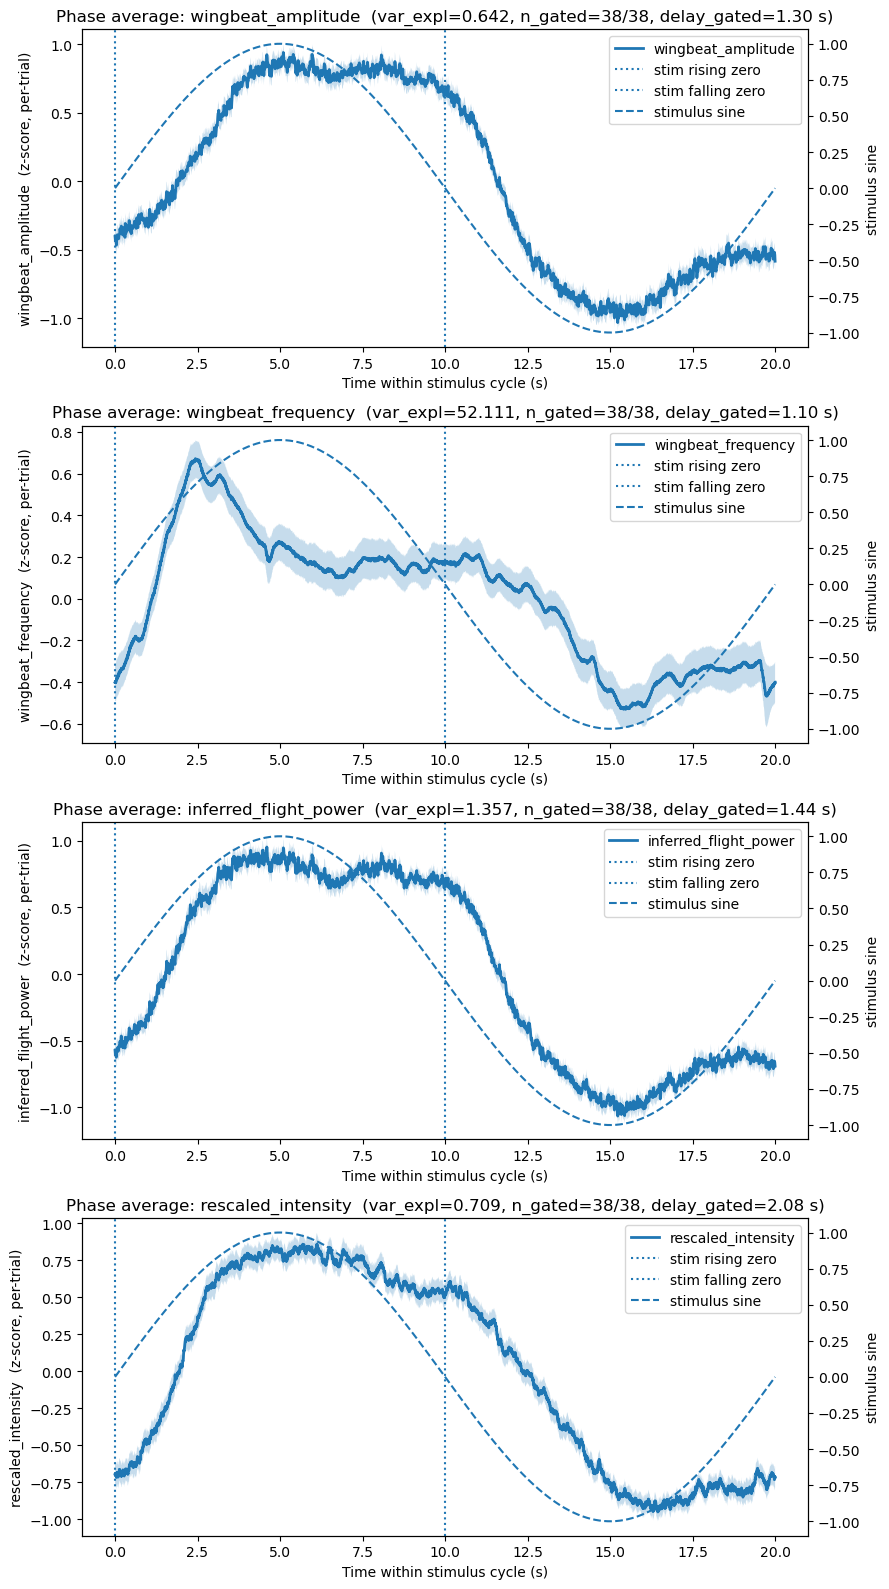

In [8]:
# Plot phase-averaged responses, normalized within trial.
#
# For each trial, z-score its three cycle traces using that trial's own
# mean/std across all three cycles. This isolates the phase-locked shape
# from between-fly baseline variance before stacking across trials.
#
# Set NORMALIZE_PER_TRIAL = False to recover the old raw-units behavior.

NORMALIZE_PER_TRIAL = True

fig, axes = plt.subplots(len(RESPONSES), 1, figsize=(9, 4 * len(RESPONSES)))

if len(RESPONSES) == 1:
    axes = [axes]

for ax1, response in zip(axes, RESPONSES):
    if NORMALIZE_PER_TRIAL:
        normalized = []
        for (trial_name, resp), traces in cycle_traces.items():
            if resp != response:
                continue
            arr = np.vstack(traces)  # (n_cycles, n_phase_samples)
            mu = np.nanmean(arr)
            sd = np.nanstd(arr)
            if not np.isfinite(sd) or sd == 0:
                continue
            normalized.extend((arr - mu) / sd)
        if len(normalized) == 0:
            print(f"{response}: nothing to plot after normalization")
            continue
        traces_mat = np.vstack(normalized)
        ylabel = f"{response}  (z-score, per-trial)"
    else:
        traces_mat = np.vstack(grand_cycle_traces[response])
        ylabel = response

    print(f"\nPlotting {response}")
    print("  traces shape:", traces_mat.shape)
    print("  finite fraction:", np.isfinite(traces_mat).mean())
    print("  min:", np.nanmin(traces_mat))
    print("  max:", np.nanmax(traces_mat))

    y_mean = np.nanmean(traces_mat, axis=0)
    y_n = np.sum(np.isfinite(traces_mat), axis=0)
    y_sem = np.nanstd(traces_mat, axis=0, ddof=1) / np.sqrt(np.maximum(y_n, 1))

    ax1.plot(phase_t, y_mean, label=response, linewidth=2)
    ax1.fill_between(
        phase_t,
        y_mean - y_sem,
        y_mean + y_sem,
        alpha=0.25,
        linewidth=0,
    )

    ax1.set_xlabel("Time within stimulus cycle (s)")
    ax1.set_ylabel(ylabel)

    ax1.axvline(0, linestyle=":", label="stim rising zero")
    ax1.axvline(PERIOD_S / 2, linestyle=":", label="stim falling zero")

    ax2 = ax1.twinx()
    ax2.plot(phase_t, stim, linestyle="--", label="stimulus sine")
    ax2.set_ylabel("stimulus sine")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    # Annotate gated stats from summary_df, if available
    summary_row = summary_df[summary_df["response"] == response]
    if len(summary_row) == 1:
        sr = summary_row.iloc[0]
        ax1.set_title(
            f"Phase average: {response}  "
            f"(var_expl={sr['across_trial_var_explained_f_mean']:.3f}, "
            f"n_gated={int(sr['n_trials_phase_meaningful'])}/{int(sr['n_trials'])}, "
            f"delay_gated={sr['across_trial_lockin_delay_circmean_s_gated']:.2f} s)"
        )
    else:
        ax1.set_title(f"Phase average: {response}")

fig.tight_layout()

suffix = "_normalized" if NORMALIZE_PER_TRIAL else ""
svg_path = DATA_DIR / f"phase_averaged_response{suffix}.svg"
fig.savefig(svg_path, format="svg")
print(f"\nSaved: {svg_path}")

plt.show()

### Block 8 (continued) — QC print of `grand_cycle_traces`

A quick quality-control print of the pooled `grand_cycle_traces` for each response signal: array shape, finite fraction, and min / max / mean. Run it when the phase-averaged traces look wrong.

---

**中文** — Block 8（续）`grand_cycle_traces` 质量检查打印

对每个响应信号汇集后的 `grand_cycle_traces` 做快速质量检查打印：数组形状、有限值比例、以及 min / max / mean。当相位平均轨迹看起来异常时运行它。

In [9]:
for response in RESPONSES:
    traces = np.vstack(grand_cycle_traces[response])
    
    print("\n", response)
    print("shape:", traces.shape)
    print("finite fraction:", np.isfinite(traces).mean())
    print("min:", np.nanmin(traces))
    print("max:", np.nanmax(traces))
    print("mean:", np.nanmean(traces))


 wingbeat_amplitude
shape: (114, 20000)
finite fraction: 1.0
min: 3.517621305553827
max: 6.026782345735403
mean: 5.0141589554007915

 wingbeat_frequency
shape: (114, 20000)
finite fraction: 0.9483565789473685
min: -1.666429225622494
max: 265.66272249899725
mean: 225.8121787617188

 inferred_flight_power
shape: (114, 20000)
finite fraction: 0.9483429824561403
min: 4.446321251717107
max: 449.48411470944416
mean: 218.73129903125982

 rescaled_intensity
shape: (114, 20000)
finite fraction: 0.9483565789473685
min: -1.0891883117489043
max: 1.3170632672301776
mean: 0.46195508047816175


## Block 9 - Per-trial delay scatter + bar across responses

Raincloud plot (scatter strip on the left, narrow box+whisker on the
right) of per-trial lock-in delay, one category per response signal.
Includes **all trials** - no coherence-gate filtering - because the
question being asked is "how delayed is each signal", not "among
trials that follow the stimulus, ...".

`DELAY_METRIC` toggles between the lock-in delay
(`trial_lockin_delay_circmean_s`, default) and the cross-correlation
delay (`xcorr_delay_mean_s`). The two should agree on tracking
trials; large divergence flags a problem.

Also prints paired t-test and Wilcoxon p-values for the three
biologically interesting pairs (amplitude vs spiracle, amplitude vs
power, power vs spiracle).

Saved as `DATA_DIR/per_trial_delay_raincloud.svg`.

---

**中文** — Block 9 逐实验延迟散点 + 跨信号条形（raincloud）

raincloud 图（左侧散点带，右侧窄箱线图），每个响应信号一类，展示逐实验 lock-in 延迟。包含**所有实验**——不做相干性门控——因为这里要问的是"每个信号有多延迟"，而非"在跟随刺激的实验中……"。

`DELAY_METRIC` 在 lock-in 延迟（`trial_lockin_delay_circmean_s`，默认）与互相关延迟（`xcorr_delay_mean_s`）之间切换。两者在跟随刺激的实验上应一致；明显分歧提示有问题。

还会打印三组生物学上关注的配对（幅度 vs 气门、幅度 vs 功率、功率 vs 气门）的配对 t 检验与 Wilcoxon p 值。

保存为 `DATA_DIR/per_trial_delay_raincloud.svg`。

Saved: C:\Users\Lylah\Desktop\data_processing\1_oscillating_visual_control\per_trial_delay_raincloud.svg


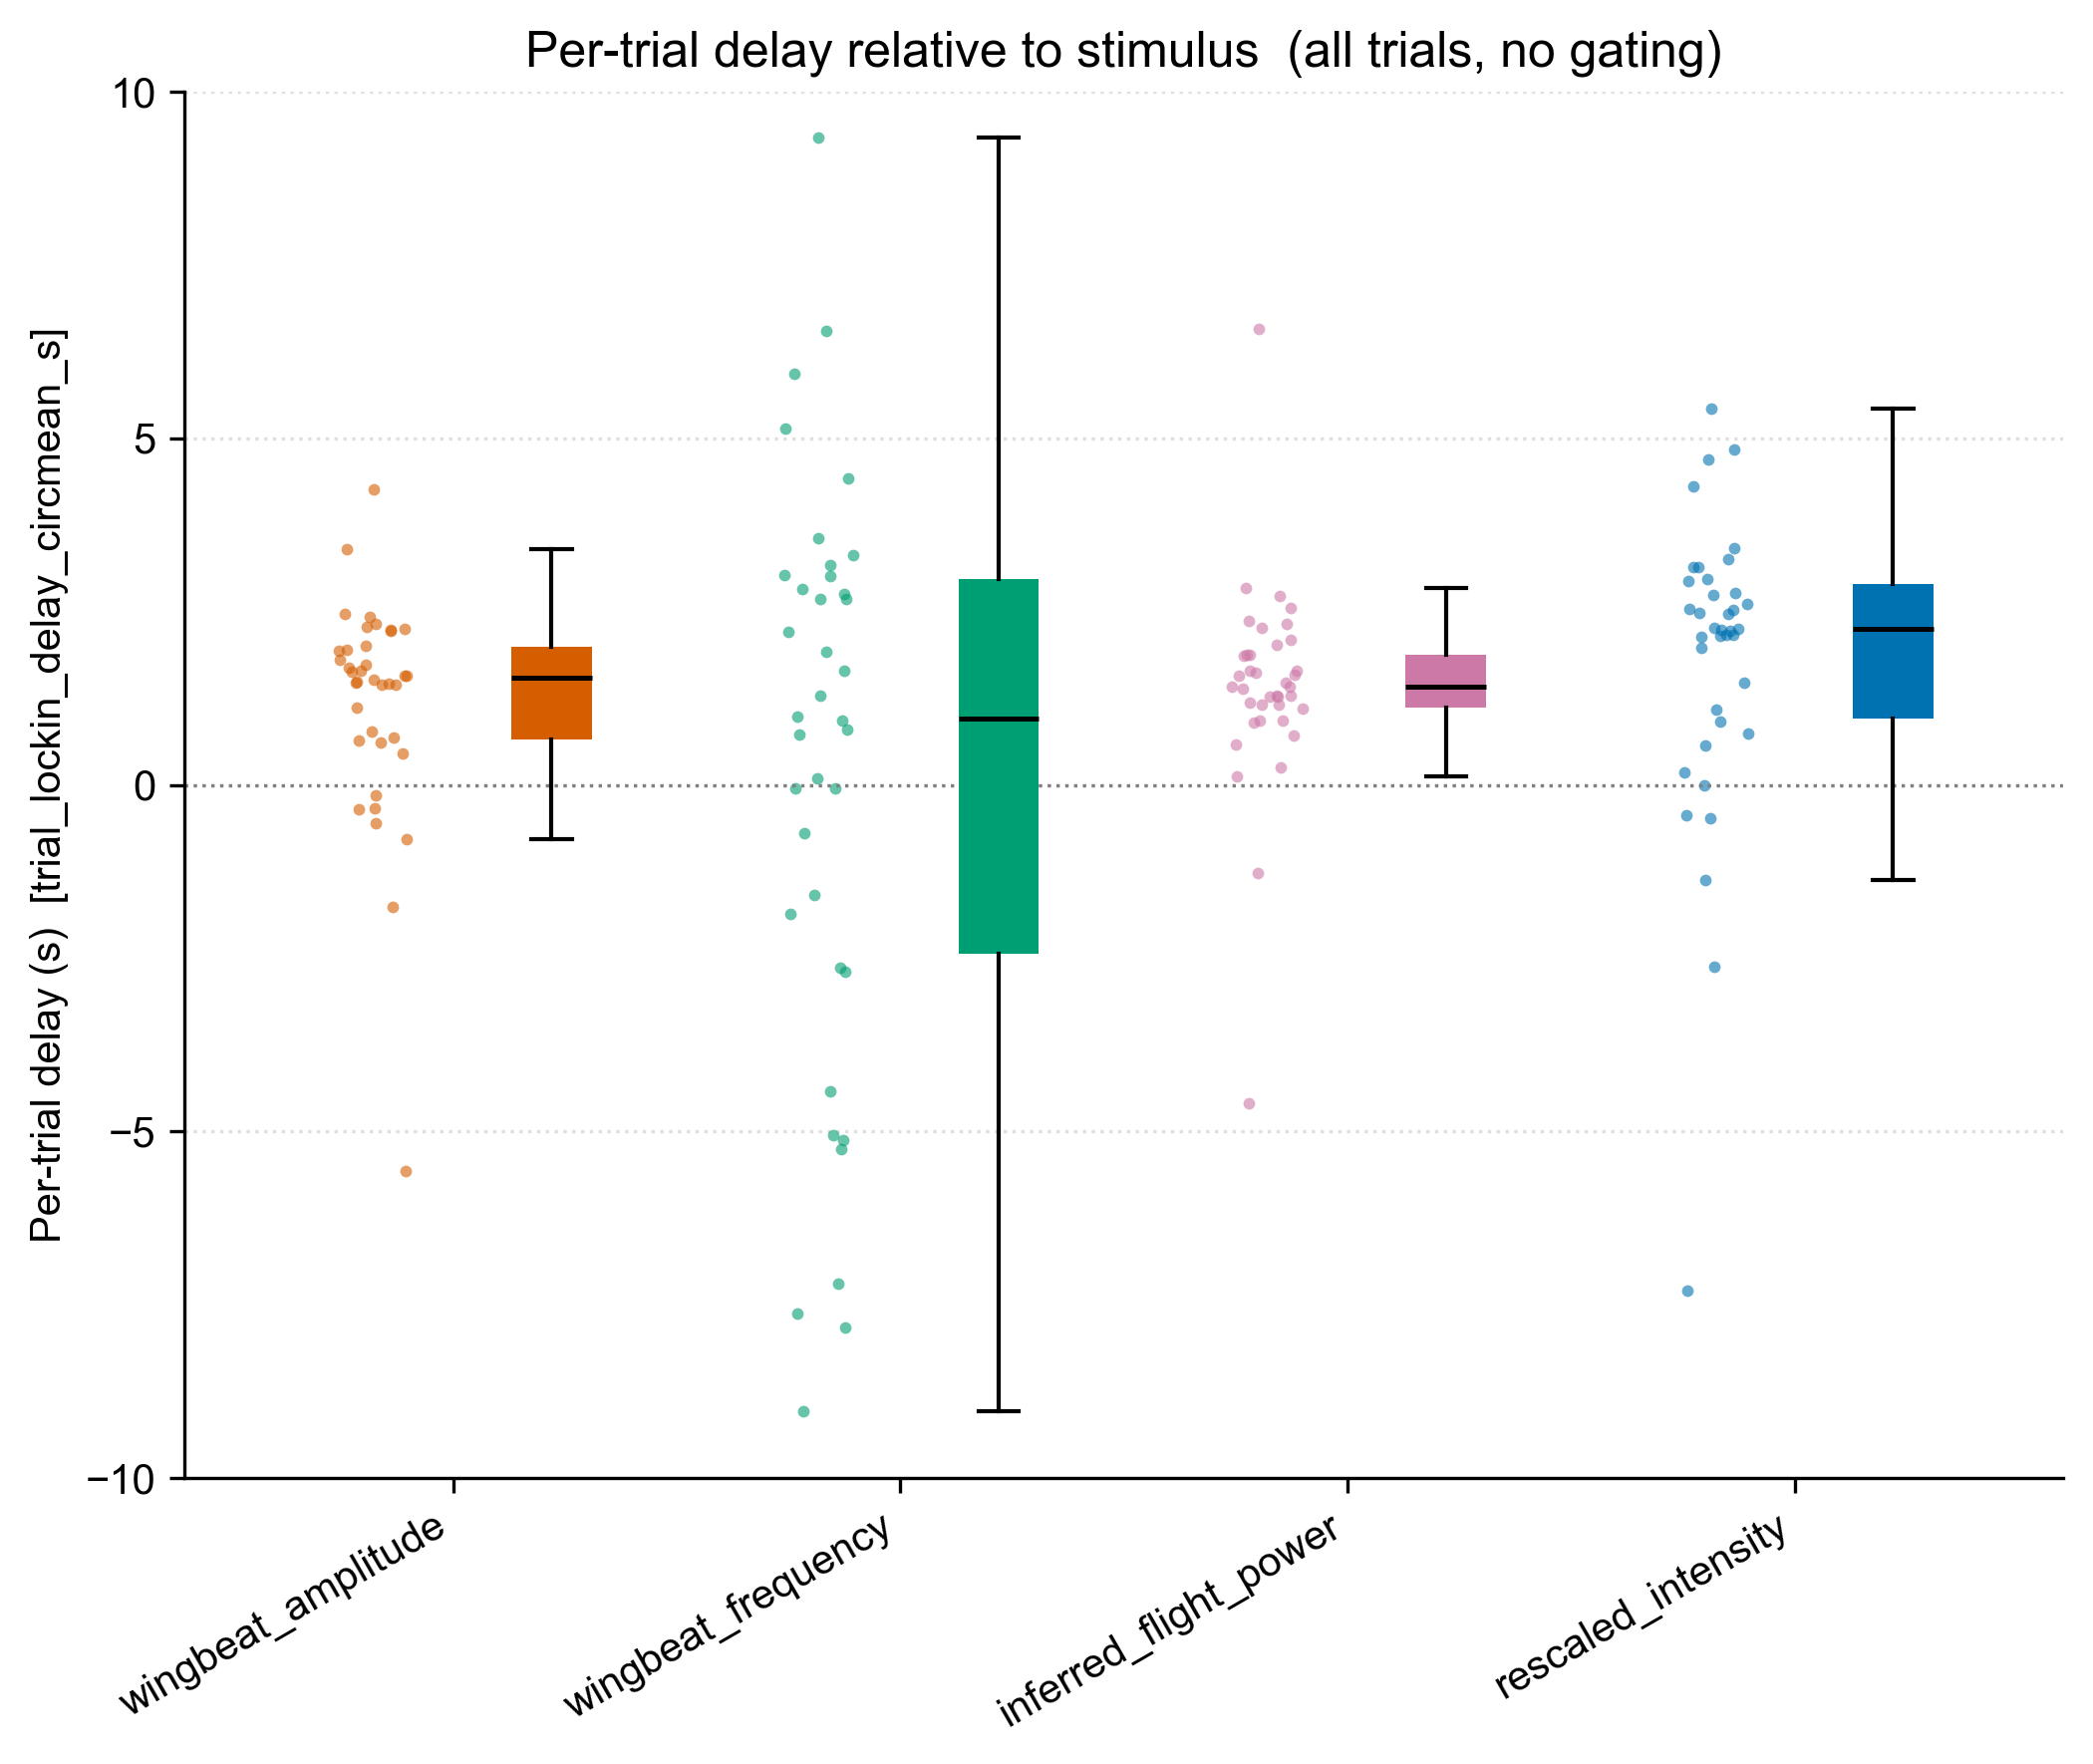


Paired comparison of per-trial delays (all trials, no gating):
  wingbeat_amplitude - rescaled_intensity: n=38, mean diff = -0.620 s (SEM 0.460), paired t p=0.1855, Wilcoxon p=0.0512
  wingbeat_amplitude - inferred_flight_power: n=38, mean diff = -0.220 s (SEM 0.303), paired t p=0.4712, Wilcoxon p=0.9886
  inferred_flight_power - rescaled_intensity: n=38, mean diff = -0.400 s (SEM 0.410), paired t p=0.3363, Wilcoxon p=0.0414


In [12]:
# Per-trial delay raincloud: scatter strip + narrow box, one pair per response.
# Includes all trials (no coherence-gate filtering).

import seaborn as sns

DELAY_METRIC = "trial_lockin_delay_circmean_s"  # alt: "xcorr_delay_mean_s"


def set_plot_style():
    """Affinity / Illustrator-safe rcParams."""
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.dpi": 300,
        "savefig.dpi": 300,
    })


RESPONSE_COLORS = {
    "wingbeat_amplitude":    "#D55E00",
    "wingbeat_frequency":    "#009E73",
    "inferred_flight_power": "#CC79A7",
    "rescaled_intensity":    "#0072B2",
}


def raincloud_strip_and_box(ax, xi, values, color, rng):
    """Draw a scatter strip (left) + narrow box+whisker (right) at category xi."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    n = len(values)
    if n == 0:
        return

    # Left: vertical scatter strip
    x_strip = xi - 0.18 + rng.uniform(-0.08, 0.08, size=n)
    ax.scatter(
        x_strip, values,
        s=8, alpha=0.6, linewidths=0, color=color,
        zorder=2,
    )

    # Right: narrow vertical box+whisker
    bp = ax.boxplot(
        [values],
        positions=[xi + 0.22],
        widths=0.18,
        vert=True,
        showfliers=False,
        patch_artist=True,
        zorder=3,
    )
    for box in bp["boxes"]:
        box.set_facecolor(color)
        box.set_edgecolor("none")
        box.set_linewidth(0)
    for whisker in bp["whiskers"]:
        whisker.set_color("black")
        whisker.set_linewidth(1.0)
    for cap in bp["caps"]:
        cap.set_color("black")
        cap.set_linewidth(1.0)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.2)


set_plot_style()

rng_jitter = np.random.default_rng(1)
categories = list(RESPONSES)
n_categories = len(categories)

fig, ax = plt.subplots(
    figsize=(max(6.0, 1.4 * n_categories + 1.5), 6.0)
)

bar_means, bar_sems, bar_ns = [], [], []

for xi, response in enumerate(categories):
    color = RESPONSE_COLORS.get(response, "#888888")

    sub = per_trial_df[per_trial_df["response"] == response]
    delays = sub[DELAY_METRIC].to_numpy()
    delays = delays[np.isfinite(delays)]
    n = len(delays)

    raincloud_strip_and_box(ax, xi, delays, color, rng_jitter)

    if n >= 1:
        mu = float(np.mean(delays))
        sem = float(np.std(delays, ddof=1) / np.sqrt(n)) if n > 1 else 0.0
    else:
        mu, sem = np.nan, np.nan
    bar_means.append(mu)
    bar_sems.append(sem)
    bar_ns.append(n)

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")

ax.set_xticks(np.arange(n_categories))
ax.set_xticklabels(categories, rotation=30, ha="right")
ax.set_xlim(-0.6, n_categories - 0.4)
ax.set_ylim(-10, 10)
ax.set_yticks(np.arange(-10, 10.001, 5))   # [-10, -5, 0, 5, 10]
ax.set_ylabel(f"Per-trial delay (s)  [{DELAY_METRIC}]")
ax.set_title("Per-trial delay relative to stimulus  (all trials, no gating)")

ax.xaxis.grid(False)
ax.yaxis.grid(True, linestyle=":", alpha=0.4)
sns.despine(ax=ax)

fig.tight_layout()

svg_path = DATA_DIR / "per_trial_delay_raincloud.svg"
fig.savefig(svg_path, dpi=300, bbox_inches="tight")
print(f"Saved: {svg_path}")

plt.show()

# Pairwise paired comparison of per-trial delays (all trials, no gating).
pivot_delay = per_trial_df.pivot_table(
    index="trial",
    columns="response",
    values=DELAY_METRIC,
    aggfunc="first",
)

print("\nPaired comparison of per-trial delays (all trials, no gating):")
for r1, r2 in [
    ("wingbeat_amplitude", "rescaled_intensity"),
    ("wingbeat_amplitude", "inferred_flight_power"),
    ("inferred_flight_power", "rescaled_intensity"),
]:
    if r1 not in pivot_delay.columns or r2 not in pivot_delay.columns:
        continue
    d1 = pivot_delay[r1].to_numpy()
    d2 = pivot_delay[r2].to_numpy()
    finite = np.isfinite(d1) & np.isfinite(d2)
    d1, d2 = d1[finite], d2[finite]
    if len(d1) < 2:
        print(f"  {r1} vs {r2}: n={len(d1)} (too few)")
        continue
    diff = d1 - d2
    tstat, pval = stats.ttest_rel(d1, d2)
    wstat, wpval = stats.wilcoxon(d1, d2) if len(d1) >= 6 else (np.nan, np.nan)
    print(
        f"  {r1} - {r2}: n={len(d1)}, "
        f"mean diff = {np.mean(diff):+.3f} s "
        f"(SEM {np.std(diff, ddof=1)/np.sqrt(len(diff)):.3f}), "
        f"paired t p={pval:.4f}, Wilcoxon p={wpval:.4f}"
    )

## Block 10 - Rise time vs fall time scatter (per-trial)

Same raincloud style as Block 9, but with two categories per signal:
10->90% rise time and 90->10% fall time. Uses only the gated trials
(rise/fall is meaningless on non-tracking responses; see Block 6).
`wingbeat_frequency` is dropped here on purpose - its rise/fall is
not interpretable.

Statistics printed and saved:

- Within-signal: paired t / Wilcoxon of fall vs rise, one row per
  signal, saved to `rise_vs_fall_stats.csv`. This is the asymmetry
  test ("does the response fall slower than it rises?").
- Between-signal: paired t / Wilcoxon of rise (and of fall) across
  pairs of signals, on trials gated in both, saved to
  `rise_fall_between_signal_stats.csv`.

Plot saved as `DATA_DIR/per_trial_rise_fall_raincloud.svg`.

---

**中文** — Block 10 上升时间 vs 下降时间散点（逐实验）

与 Block 9 同样的 raincloud 风格，但每个信号两类：10→90% 上升时间与 90→10% 下降时间。仅用门控通过的实验（在不跟随刺激的响应上谈上升/下降无意义；见 Block 6）。这里有意丢弃 `wingbeat_frequency`——其上升/下降不可解释。

打印并保存的统计：

- 信号内：每个信号一行的下降 vs 上升配对 t / Wilcoxon，保存到 `rise_vs_fall_stats.csv`。这是不对称性检验（"响应下降是否比上升慢？"）。
- 信号间：在两信号都门控通过的实验上，对上升（及下降）做跨信号配对 t / Wilcoxon，保存到 `rise_fall_between_signal_stats.csv`。

图保存为 `DATA_DIR/per_trial_rise_fall_raincloud.svg`。

Saved: C:\Users\Lylah\Desktop\data_processing\1_oscillating_visual_control\per_trial_rise_fall_raincloud.svg


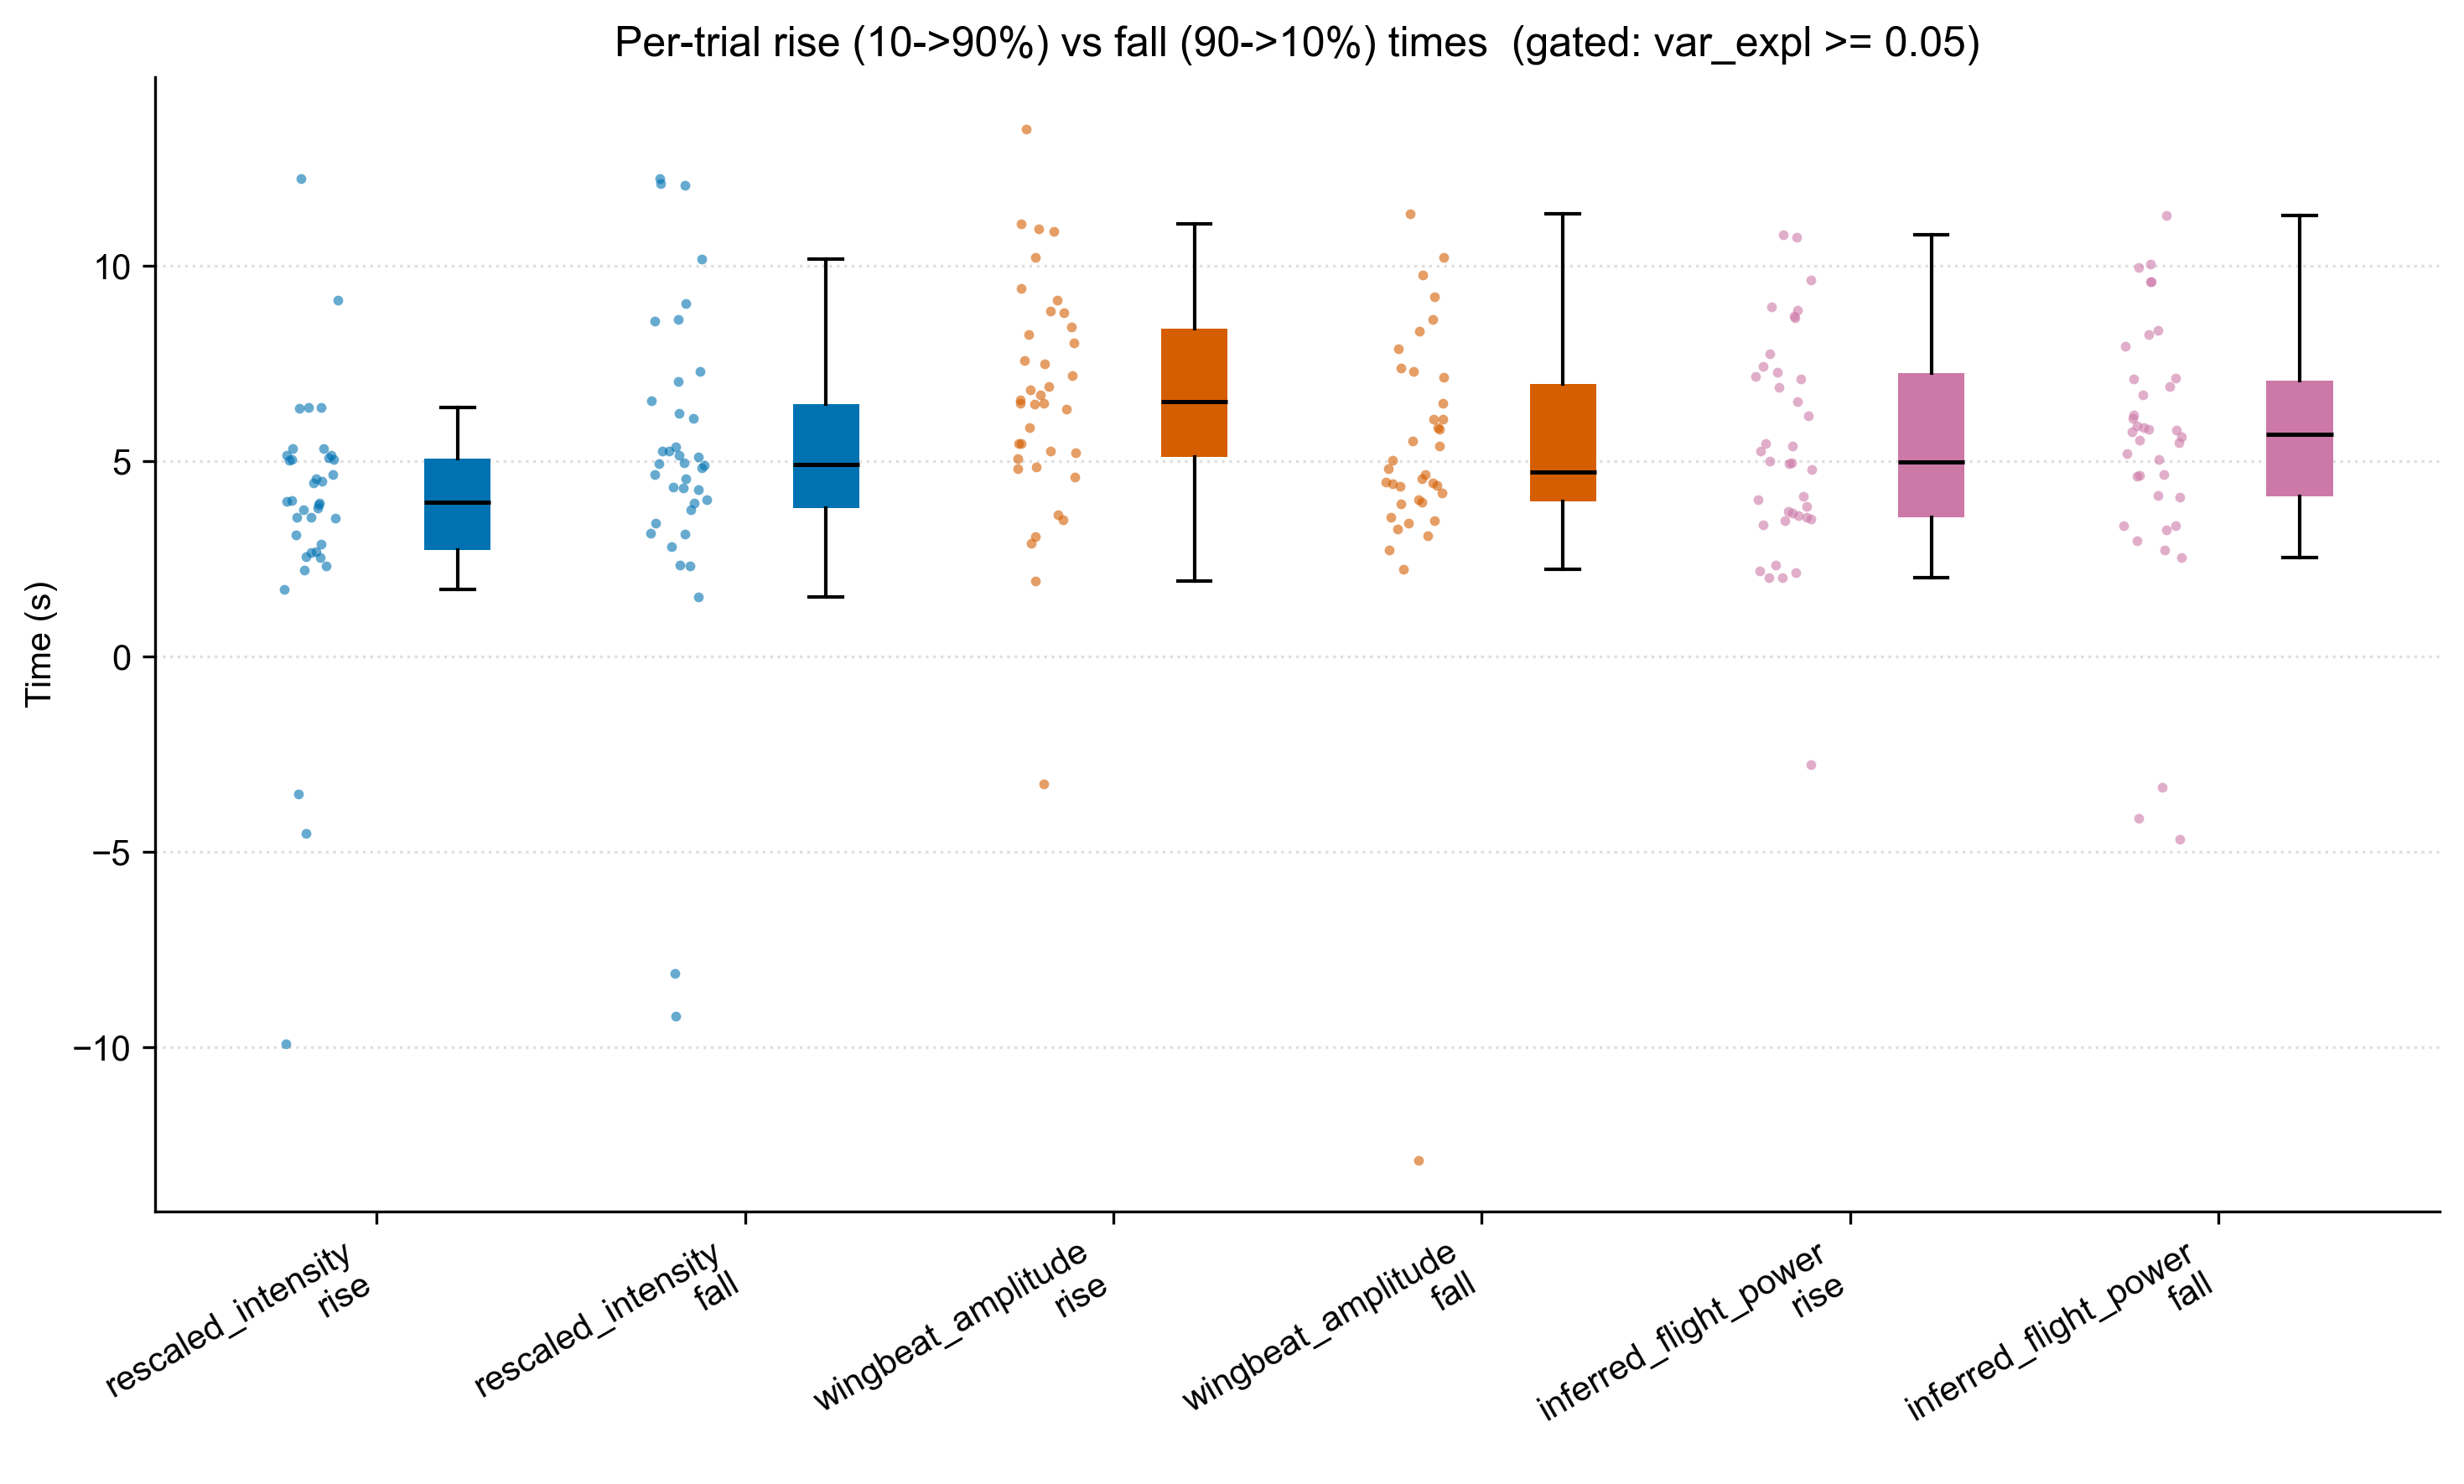


Within-signal rise vs fall (paired, gated trials):
  rescaled_intensity: n=38, rise = 3.650 +/- 0.573 s, fall = 4.928 +/- 0.683 s, fall - rise = +1.278 s, paired t p=0.1049, Wilcoxon p=0.0429
  wingbeat_amplitude: n=38, rise = 6.607 +/- 0.489 s, fall = 5.123 +/- 0.605 s, fall - rise = -1.484 s, paired t p=0.0374, Wilcoxon p=0.0512
  inferred_flight_power: n=38, rise = 5.355 +/- 0.459 s, fall = 5.250 +/- 0.569 s, fall - rise = -0.105 s, paired t p=0.8784, Wilcoxon p=0.8860

Saved: C:\Users\Lylah\Desktop\data_processing\1_oscillating_visual_control\phase_analysis_individual_trials_simple\rise_vs_fall_stats.csv

Between-signal rise / fall comparison (paired, both gated):
  rise: wingbeat_amplitude - rescaled_intensity: n=38, mean diff = +2.957 s, paired t p=0.0006, Wilcoxon p=0.0002
  fall: wingbeat_amplitude - rescaled_intensity: n=38, mean diff = +0.195 s, paired t p=0.8435, Wilcoxon p=0.9087
  rise: wingbeat_amplitude - inferred_flight_power: n=38, mean diff = +1.252 s, paired t p=0.0

In [13]:
# Per-trial rise (10->90%) and fall (90->10%) raincloud, by signal.
# Each signal contributes two categories: rise and fall.
# Each category gets a scatter strip + narrow box+whisker, colored by signal.

RF_RESPONSES = ["rescaled_intensity", "wingbeat_amplitude", "inferred_flight_power"]

set_plot_style()

# Build flat category list in insertion order: (label, color, values)
rf_categories = []
for response in RF_RESPONSES:
    sub = per_trial_df[
        (per_trial_df["response"] == response) &
        (per_trial_df["phase_is_meaningful"])
    ]
    rise = sub["rise_time_10_90_s"].to_numpy()
    fall = sub["fall_time_90_10_s"].to_numpy()
    finite = np.isfinite(rise) & np.isfinite(fall)
    rise, fall = rise[finite], fall[finite]

    color = RESPONSE_COLORS.get(response, "#888888")
    rf_categories.append((f"{response}\nrise", color, rise))
    rf_categories.append((f"{response}\nfall", color, fall))

n_categories = len(rf_categories)
rng_jitter = np.random.default_rng(2)

fig, ax = plt.subplots(
    figsize=(max(6.0, 1.4 * n_categories + 1.5), 6.0)
)

for xi, (label, color, values) in enumerate(rf_categories):
    raincloud_strip_and_box(ax, xi, values, color, rng_jitter)

ax.set_xticks(np.arange(n_categories))
ax.set_xticklabels([c[0] for c in rf_categories], rotation=30, ha="right")
ax.set_xlim(-0.6, n_categories - 0.4)
ax.set_ylabel("Time (s)")
ax.set_title(
    f"Per-trial rise (10->90%) vs fall (90->10%) times  "
    f"(gated: var_expl >= {COHERENCE_MIN_VAR_EXPLAINED})"
)

ax.xaxis.grid(False)
ax.yaxis.grid(True, linestyle=":", alpha=0.4)
sns.despine(ax=ax)

fig.tight_layout()

svg_path = DATA_DIR / "per_trial_rise_fall_raincloud.svg"
fig.savefig(svg_path, dpi=300, bbox_inches="tight")
print(f"Saved: {svg_path}")

plt.show()


# ---------------------------------------------------------------------------
# Within-signal paired tests: rise vs fall (per trial, gated trials only)
# ---------------------------------------------------------------------------
within_signal_stats = []
for response in RF_RESPONSES:
    sub = per_trial_df[
        (per_trial_df["response"] == response) &
        (per_trial_df["phase_is_meaningful"])
    ]
    rise = sub["rise_time_10_90_s"].to_numpy()
    fall = sub["fall_time_90_10_s"].to_numpy()
    finite = np.isfinite(rise) & np.isfinite(fall)
    rise, fall = rise[finite], fall[finite]
    n = len(rise)
    if n == 0:
        continue

    mu_r, mu_f = float(np.mean(rise)), float(np.mean(fall))
    sem_r = float(np.std(rise, ddof=1) / np.sqrt(n)) if n > 1 else 0.0
    sem_f = float(np.std(fall, ddof=1) / np.sqrt(n)) if n > 1 else 0.0
    tstat, pval = stats.ttest_rel(fall, rise) if n >= 2 else (np.nan, np.nan)
    wstat, wpval = stats.wilcoxon(fall, rise) if n >= 6 else (np.nan, np.nan)

    within_signal_stats.append({
        "response": response,
        "n": n,
        "rise_mean_s": mu_r,
        "rise_sem_s": sem_r,
        "fall_mean_s": mu_f,
        "fall_sem_s": sem_f,
        "fall_minus_rise_mean_s": mu_f - mu_r,
        "fall_minus_rise_sem_s": float(np.std(fall - rise, ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
        "paired_t_stat": tstat,
        "paired_t_pvalue": pval,
        "wilcoxon_stat": wstat,
        "wilcoxon_pvalue": wpval,
    })

print("\nWithin-signal rise vs fall (paired, gated trials):")
for row in within_signal_stats:
    print(
        f"  {row['response']}: n={row['n']}, "
        f"rise = {row['rise_mean_s']:.3f} +/- {row['rise_sem_s']:.3f} s, "
        f"fall = {row['fall_mean_s']:.3f} +/- {row['fall_sem_s']:.3f} s, "
        f"fall - rise = {row['fall_minus_rise_mean_s']:+.3f} s, "
        f"paired t p={row['paired_t_pvalue']:.4f}, "
        f"Wilcoxon p={row['wilcoxon_pvalue']:.4f}"
    )

within_signal_stats_df = pd.DataFrame(within_signal_stats)
rise_fall_csv = OUT_DIR / "rise_vs_fall_stats.csv"
within_signal_stats_df.to_csv(rise_fall_csv, index=False)
print(f"\nSaved: {rise_fall_csv}")


# ---------------------------------------------------------------------------
# Between-signal paired tests (kept for reference): rise / fall on trials
# gated in BOTH signals.
# ---------------------------------------------------------------------------
pivot_rise = per_trial_df.pivot_table(
    index="trial", columns="response", values="rise_time_10_90_s", aggfunc="first"
)
pivot_fall = per_trial_df.pivot_table(
    index="trial", columns="response", values="fall_time_90_10_s", aggfunc="first"
)
pivot_gated = per_trial_df.pivot_table(
    index="trial", columns="response", values="phase_is_meaningful", aggfunc="first"
)

between_signal_stats = []
print("\nBetween-signal rise / fall comparison (paired, both gated):")
for r1, r2 in [
    ("wingbeat_amplitude", "rescaled_intensity"),
    ("wingbeat_amplitude", "inferred_flight_power"),
    ("inferred_flight_power", "rescaled_intensity"),
]:
    if r1 not in pivot_rise.columns or r2 not in pivot_rise.columns:
        continue
    both_gated = pivot_gated[r1].fillna(False) & pivot_gated[r2].fillna(False)
    for label, pivot in [("rise", pivot_rise), ("fall", pivot_fall)]:
        a = pivot.loc[both_gated, r1].to_numpy()
        b = pivot.loc[both_gated, r2].to_numpy()
        finite = np.isfinite(a) & np.isfinite(b)
        a, b = a[finite], b[finite]
        if len(a) < 2:
            print(f"  {label}: {r1} vs {r2}: n={len(a)} (too few)")
            continue
        tstat, pval = stats.ttest_rel(a, b)
        wstat, wpval = stats.wilcoxon(a, b) if len(a) >= 6 else (np.nan, np.nan)
        print(
            f"  {label}: {r1} - {r2}: n={len(a)}, "
            f"mean diff = {np.mean(a - b):+.3f} s, "
            f"paired t p={pval:.4f}, Wilcoxon p={wpval:.4f}"
        )
        between_signal_stats.append({
            "metric": label,
            "response_a": r1,
            "response_b": r2,
            "n": int(len(a)),
            "mean_diff_s": float(np.mean(a - b)),
            "paired_t_stat": float(tstat),
            "paired_t_pvalue": float(pval),
            "wilcoxon_stat": float(wstat) if np.isfinite(wstat) else np.nan,
            "wilcoxon_pvalue": float(wpval) if np.isfinite(wpval) else np.nan,
        })

between_csv = OUT_DIR / "rise_fall_between_signal_stats.csv"
pd.DataFrame(between_signal_stats).to_csv(between_csv, index=False)
print(f"\nSaved: {between_csv}")

## Block 11 - Per-trial Pearson r (sine vs signal)

Reads `DATA_DIR/pearson_correlations_20_80s.csv`, written by **Block 10
of `step2_phantom_video_analysis_visualization_oscillation.ipynb`**.
That CSV contains a per-trial Pearson r between the visual sine and
each of the four signals over the 20-80 s window (the part of the
trial that contains the three stimulus cycles).

This block re-uses the raincloud style from Block 9 to plot the
distribution of those r values, one category per signal. It is a
coarser, lag-free check on the lock-in delays from Blocks 4 and 9:
if a signal tracks the sine, |r| should be away from 0 even before
accounting for delay.

If `pearson_correlations_20_80s.csv` is missing, re-run step2's Block
10 first; this notebook does not regenerate it.

Saved as `DATA_DIR/per_trial_pearson_r_raincloud.svg`.

---

**中文** — Block 11 逐实验皮尔逊 r（正弦 vs 信号）

读取 `DATA_DIR/pearson_correlations_20_80s.csv`（由 **Step2B / `step2_..._oscillation.ipynb` 的 Block 10** 写出）。该 CSV 含每次实验中视觉正弦与四个信号在 20–80 s 窗（含三个刺激周期）内的皮尔逊 r。

本块复用 Block 9 的 raincloud 风格绘制这些 r 值的分布，每个信号一类。它是对 Block 4 与 9 中 lock-in 延迟的一个更粗、不含延迟的检查：若某信号跟随正弦，则即便未计延迟，|r| 也应偏离 0。

若缺少 `pearson_correlations_20_80s.csv`，请先重跑 Step2 的 Block 10；本 notebook 不会重新生成它。

保存为 `DATA_DIR/per_trial_pearson_r_raincloud.svg`。

Saved: C:\Users\Lylah\Desktop\data_processing\1_oscillating_visual_control\per_trial_pearson_r_raincloud.svg


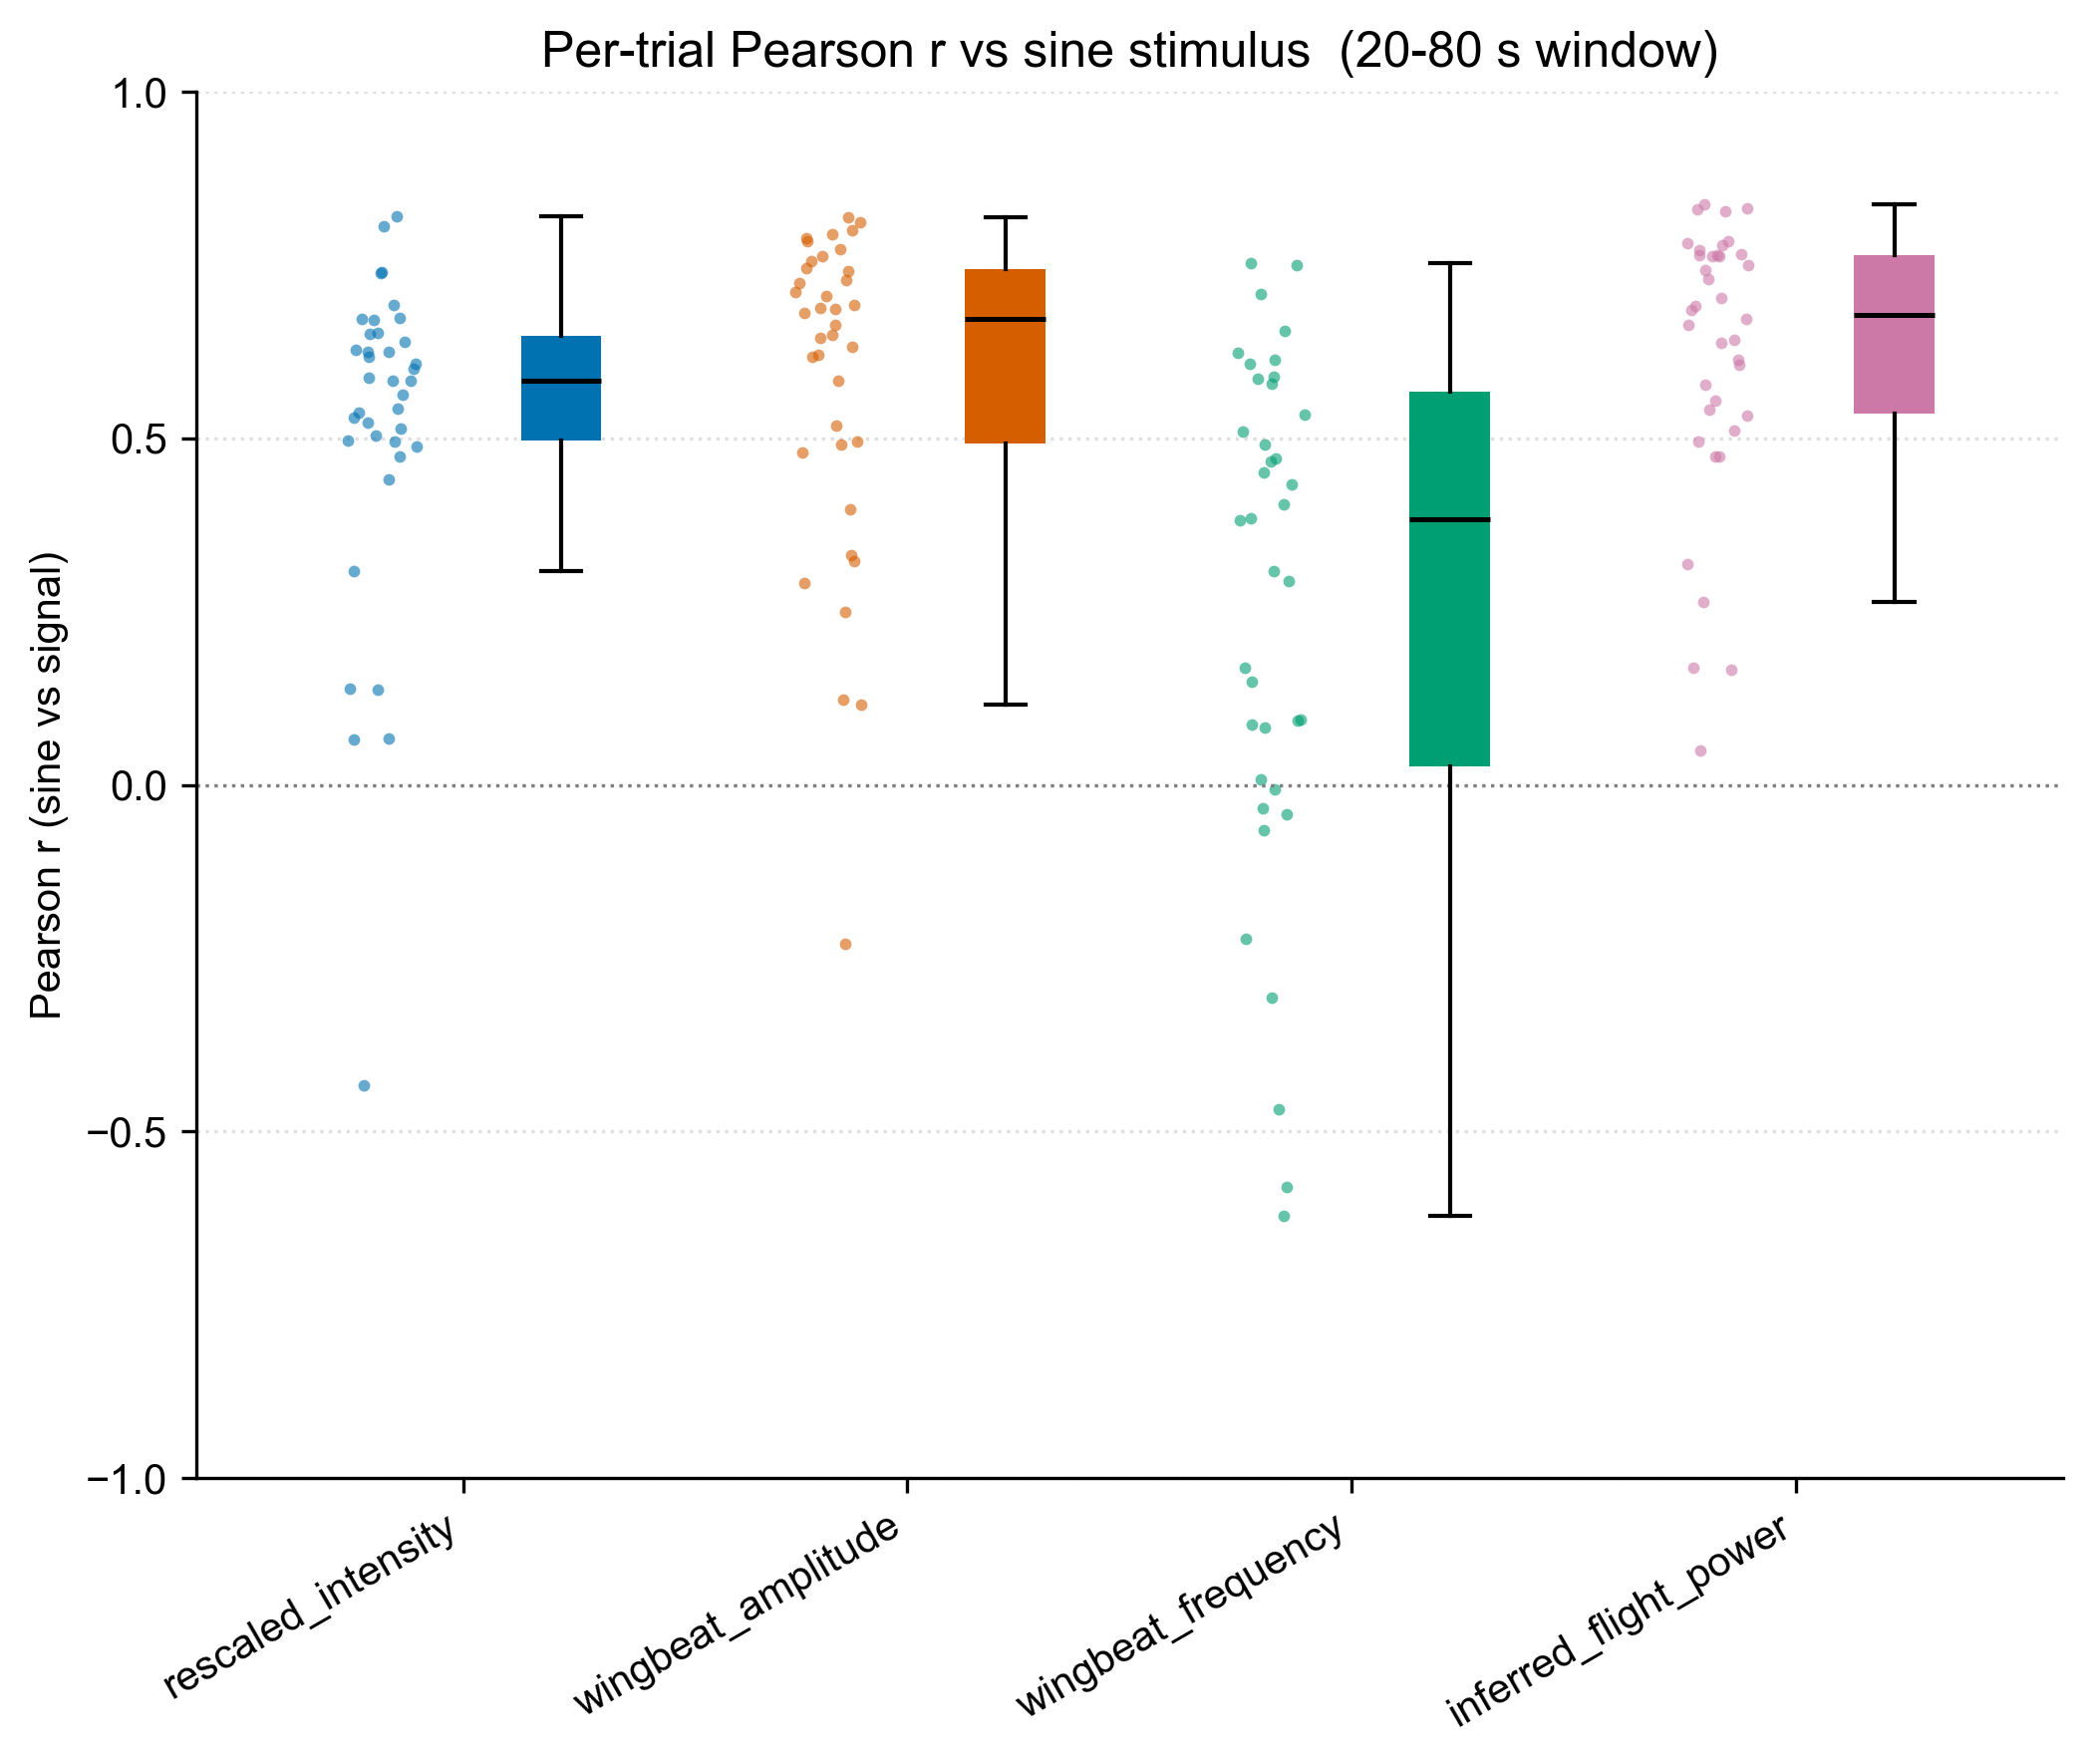


Per-signal Pearson r (sine vs signal), 20-80 s:
  rescaled_intensity: n=38, mean r = +0.516 +/- 0.039 (SEM), SD = 0.241
  wingbeat_amplitude: n=38, mean r = +0.584 +/- 0.038 (SEM), SD = 0.235
  wingbeat_frequency: n=38, mean r = +0.261 +/- 0.060 (SEM), SD = 0.370
  inferred_flight_power: n=38, mean r = +0.619 +/- 0.033 (SEM), SD = 0.201


In [14]:
# Per-trial Pearson r between the sine stimulus and each of four signals,
# over the 20-80 s window. Reads the CSV written by Block 10 of
# step2_phantom_video_analysis_visualization_oscillation.ipynb.

PEARSON_CSV = DATA_DIR / "pearson_correlations_20_80s.csv"

pearson_df = pd.read_csv(PEARSON_CSV)

# Category order matches user's request: spiracle, amp, freq, power.
PEARSON_COLS = [
    ("rescaled_intensity",    "r_sine_vs_rescaled_intensity"),
    ("wingbeat_amplitude",    "r_sine_vs_wingbeat_amplitude"),
    ("wingbeat_frequency",    "r_sine_vs_wingbeat_frequency"),
    ("inferred_flight_power", "r_sine_vs_inferred_flight_power"),
]

set_plot_style()

n_categories = len(PEARSON_COLS)
rng_jitter = np.random.default_rng(3)

fig, ax = plt.subplots(
    figsize=(max(6.0, 1.4 * n_categories + 1.5), 6.0)
)

for xi, (label, col) in enumerate(PEARSON_COLS):
    color = RESPONSE_COLORS.get(label, "#888888")
    r_vals = pd.to_numeric(pearson_df[col], errors="coerce").to_numpy()
    raincloud_strip_and_box(ax, xi, r_vals, color, rng_jitter)

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")

ax.set_xticks(np.arange(n_categories))
ax.set_xticklabels([c[0] for c in PEARSON_COLS], rotation=30, ha="right")
ax.set_xlim(-0.6, n_categories - 0.4)
ax.set_ylim(-1, 1)
ax.set_yticks(np.arange(-1, 1.001, 0.5))   # [-1, -0.5, 0, 0.5, 1]
ax.set_ylabel("Pearson r (sine vs signal)")
ax.set_title("Per-trial Pearson r vs sine stimulus  (20-80 s window)")

ax.xaxis.grid(False)
ax.yaxis.grid(True, linestyle=":", alpha=0.4)
sns.despine(ax=ax)

fig.tight_layout()

svg_path = DATA_DIR / "per_trial_pearson_r_raincloud.svg"
fig.savefig(svg_path, dpi=300, bbox_inches="tight")
print(f"Saved: {svg_path}")

plt.show()

# Per-signal summary stats
print("\nPer-signal Pearson r (sine vs signal), 20-80 s:")
for label, col in PEARSON_COLS:
    r_vals = pd.to_numeric(pearson_df[col], errors="coerce").to_numpy()
    r_vals = r_vals[np.isfinite(r_vals)]
    n = len(r_vals)
    if n == 0:
        print(f"  {label}: n=0")
        continue
    mu = float(np.mean(r_vals))
    sd = float(np.std(r_vals, ddof=1)) if n > 1 else 0.0
    sem = sd / np.sqrt(n) if n > 1 else 0.0
    print(f"  {label}: n={n}, mean r = {mu:+.3f} +/- {sem:.3f} (SEM), SD = {sd:.3f}")